<a href="https://colab.research.google.com/github/ibrahimbarghout/robust-ecg-domain-generalization/blob/main/notebooks/10_ECG_Deep_Learning_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.8 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
# ============================================================
# NOTEBOOK 10 — RAW 12-LEAD DEEP LEARNING
# STEP 10A — ENVIRONMENT & GPU VERIFICATION
# ============================================================

import os
import sys
import platform
import numpy as np
import pandas as pd
import scipy
import sklearn
import torch
import wfdb

print("=" * 70)
print("STEP 10A — ENVIRONMENT & GPU VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Python / platform
# ------------------------------------------------------------

print("\nSYSTEM")
print("-" * 70)

print("Python:", sys.version)
print("Platform:", platform.platform())

# ------------------------------------------------------------
# 2. Core package versions
# ------------------------------------------------------------

print("\nPACKAGES")
print("-" * 70)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("WFDB:", wfdb.__version__)

# ------------------------------------------------------------
# 3. CUDA / GPU
# ------------------------------------------------------------

print("\nPYTORCH / CUDA")
print("-" * 70)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

print(
    "PyTorch CUDA version:",
    torch.version.cuda
)

print(
    "CUDA device count:",
    torch.cuda.device_count()
)

if torch.cuda.is_available():

    for i in range(torch.cuda.device_count()):

        props = torch.cuda.get_device_properties(i)

        print(
            f"\nGPU {i}: {props.name}"
        )

        print(
            f"  Compute capability: "
            f"{props.major}.{props.minor}"
        )

        print(
            f"  Total memory: "
            f"{props.total_memory / 1024**3:.2f} GB"
        )

    DEVICE_10A = torch.device("cuda")

else:

    DEVICE_10A = torch.device("cpu")

    print(
        "\nWARNING: No CUDA GPU detected."
    )

print(
    "\nSelected device:",
    DEVICE_10A
)

# ------------------------------------------------------------
# 4. Basic PyTorch tensor test
# ------------------------------------------------------------

print("\nPYTORCH DEVICE TEST")
print("-" * 70)

test_tensor_10a = torch.tensor(
    [1.0, 2.0, 3.0],
    dtype=torch.float32,
    device=DEVICE_10A
)

test_result_10a = (
    test_tensor_10a * 2
).sum().item()

if test_result_10a != 12.0:
    raise RuntimeError(
        "PyTorch device computation failed."
    )

print(
    "Tensor computation: PASS"
)

# ------------------------------------------------------------
# 5. Reproducibility configuration
# ------------------------------------------------------------

RANDOM_SEED_10A = 42

np.random.seed(RANDOM_SEED_10A)
torch.manual_seed(RANDOM_SEED_10A)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RANDOM_SEED_10A
    )

print(
    "Random seed:",
    RANDOM_SEED_10A
)

# ------------------------------------------------------------
# 6. Project paths
# ------------------------------------------------------------

PROJECT_PATH_10A = (
    "/content/drive/MyDrive/"
    "PTB-XL Research Project"
)

DATA_PATH_10A = os.path.join(
    PROJECT_PATH_10A,
    "data",
    "ptb-xl-a-large-publicly-available-"
    "electrocardiography-dataset-1.0.3"
)

RESULTS_PATH_10A = os.path.join(
    PROJECT_PATH_10A,
    "results"
)

SPLIT_PATH_10A = os.path.join(
    RESULTS_PATH_10A,
    "ptbxl_patient_independent_split.csv"
)

TARGETS_PATH_10A = os.path.join(
    RESULTS_PATH_10A,
    "ptbxl_diagnostic_targets.csv"
)

print("\nPROJECT PATHS")
print("-" * 70)

print(
    "Project exists:",
    os.path.exists(PROJECT_PATH_10A)
)

print(
    "Dataset exists:",
    os.path.exists(DATA_PATH_10A)
)

print(
    "Split artifact exists:",
    os.path.exists(SPLIT_PATH_10A)
)

print(
    "Target artifact exists:",
    os.path.exists(TARGETS_PATH_10A)
)

if not os.path.exists(DATA_PATH_10A):
    raise FileNotFoundError(
        "PTB-XL dataset directory not found."
    )

if not os.path.exists(SPLIT_PATH_10A):
    raise FileNotFoundError(
        "Patient-independent split artifact not found."
    )

if not os.path.exists(TARGETS_PATH_10A):
    raise FileNotFoundError(
        "Diagnostic target artifact not found."
    )

# ------------------------------------------------------------
# 7. Create deep-learning result directory
# ------------------------------------------------------------

DEEP_LEARNING_RESULTS_PATH_10A = os.path.join(
    RESULTS_PATH_10A,
    "deep_learning"
)

os.makedirs(
    DEEP_LEARNING_RESULTS_PATH_10A,
    exist_ok=True
)

print(
    "\nDeep-learning results directory:",
    DEEP_LEARNING_RESULTS_PATH_10A
)

# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10A STATUS: PASS")
print("=" * 70)

print(
    "Environment verified."
)

print(
    "Project artifacts accessible."
)

print(
    "PyTorch device test completed."
)

print(
    "No ECG data loaded or model training performed."
)

STEP 10A — ENVIRONMENT & GPU VERIFICATION

SYSTEM
----------------------------------------------------------------------
Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35

PACKAGES
----------------------------------------------------------------------
NumPy: 2.1.3
Pandas: 2.2.3
SciPy: 1.16.3
Scikit-learn: 1.6.1
PyTorch: 2.11.0+cu128
WFDB: 4.3.1

PYTORCH / CUDA
----------------------------------------------------------------------
CUDA available: True
PyTorch CUDA version: 12.8
CUDA device count: 1

GPU 0: Tesla T4
  Compute capability: 7.5
  Total memory: 14.56 GB

Selected device: cuda

PYTORCH DEVICE TEST
----------------------------------------------------------------------
Tensor computation: PASS
Random seed: 42

PROJECT PATHS
----------------------------------------------------------------------
Project exists: True
Dataset exists: True
Split artifact exists: True
Target artifact exists: True

Deep-learning results directory

In [7]:
# ============================================================
# STEP 10B — RAW ECG DATASET PIPELINE
# Corrected: use PTB-XL filename_hr metadata
# ============================================================

import os
import numpy as np
import pandas as pd
import wfdb

print("=" * 70)
print("STEP 10B — RAW ECG DATASET PIPELINE")
print("=" * 70)

# ------------------------------------------------------------
# 1. LOAD FROZEN SPLIT AND TARGET ARTIFACTS
# ------------------------------------------------------------

split_10B = pd.read_csv(SPLIT_PATH_10A)
targets_10B = pd.read_csv(TARGETS_PATH_10A)

print("\nARTIFACTS")
print("-" * 70)
print(f"Split shape:   {split_10B.shape}")
print(f"Target shape:  {targets_10B.shape}")

# ------------------------------------------------------------
# 2. LOAD PTB-XL METADATA
# ------------------------------------------------------------

metadata_10B = pd.read_csv(
    os.path.join(DATA_PATH_10A, "ptbxl_database.csv")
)

print(f"Metadata shape: {metadata_10B.shape}")

assert "ecg_id" in metadata_10B.columns
assert "patient_id" in metadata_10B.columns
assert "filename_hr" in metadata_10B.columns

assert metadata_10B["ecg_id"].is_unique

print("PTB-XL metadata: PASS")
print("filename_hr available: PASS")

# ------------------------------------------------------------
# 3. VERIFY EXPECTED COLUMNS
# ------------------------------------------------------------

EXPECTED_SPLIT_COLUMNS_10B = [
    "ecg_id",
    "patient_id",
    "strat_fold",
    "split"
]

EXPECTED_TARGET_COLUMNS_10B = [
    "ecg_id",
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP",
    "ABNORMAL",
    "REFERENCE_NORMAL"
]

TARGET_COLUMNS_10B = [
    "MI",
    "STTC",
    "CD",
    "HYP",
    "NORM"
]

assert list(split_10B.columns) == EXPECTED_SPLIT_COLUMNS_10B
assert list(targets_10B.columns) == EXPECTED_TARGET_COLUMNS_10B

print("Split columns: PASS")
print("Target columns: PASS")

# ------------------------------------------------------------
# 4. VERIFY DATASET SIZE
# ------------------------------------------------------------

assert len(split_10B) == 21799
assert len(targets_10B) == 21799

split_counts_10B = split_10B["split"].value_counts()

assert split_counts_10B.get("train", 0) == 17418
assert split_counts_10B.get("validation", 0) == 2183
assert split_counts_10B.get("test", 0) == 2198

print("\nDATASET SIZE")
print("-" * 70)
print(f"Total ECGs: {len(split_10B):,}")
print(f"Train:      {split_counts_10B['train']:,}")
print(f"Validation: {split_counts_10B['validation']:,}")
print(f"Test:       {split_counts_10B['test']:,}")
print("Split counts: PASS")

# ------------------------------------------------------------
# 5. VERIFY ECG ID ALIGNMENT
# ------------------------------------------------------------

assert split_10B["ecg_id"].is_unique
assert targets_10B["ecg_id"].is_unique

assert set(split_10B["ecg_id"]) == set(targets_10B["ecg_id"])

print("\nECG ID ALIGNMENT")
print("-" * 70)
print("Unique split ECG IDs: PASS")
print("Unique target ECG IDs: PASS")
print("Split/target ECG ID sets identical: PASS")

# ------------------------------------------------------------
# 6. VERIFY PATIENT INDEPENDENCE
# ------------------------------------------------------------

train_patients_10B = set(
    split_10B.loc[
        split_10B["split"] == "train",
        "patient_id"
    ]
)

val_patients_10B = set(
    split_10B.loc[
        split_10B["split"] == "validation",
        "patient_id"
    ]
)

test_patients_10B = set(
    split_10B.loc[
        split_10B["split"] == "test",
        "patient_id"
    ]
)

assert len(train_patients_10B & val_patients_10B) == 0
assert len(train_patients_10B & test_patients_10B) == 0
assert len(val_patients_10B & test_patients_10B) == 0

print("\nPATIENT INDEPENDENCE")
print("-" * 70)
print(f"Train patients:      {len(train_patients_10B):,}")
print(f"Validation patients: {len(val_patients_10B):,}")
print(f"Test patients:       {len(test_patients_10B):,}")
print("Train ↔ Validation overlap: 0")
print("Train ↔ Test overlap:       0")
print("Validation ↔ Test overlap:  0")
print("Patient independence: PASS")

# ------------------------------------------------------------
# 7. VERIFY TARGETS
# ------------------------------------------------------------

for target in TARGET_COLUMNS_10B:
    unique_values = set(targets_10B[target].dropna().unique())
    assert unique_values.issubset({0, 1}), (
        f"{target} contains non-binary values: {unique_values}"
    )

print("\nTARGETS")
print("-" * 70)
print("Targets: MI, STTC, CD, HYP, NORM")
print("Binary encoding: PASS")

# ------------------------------------------------------------
# 8. MERGE SPLIT WITH CANONICAL PTB-XL FILENAMES
# ------------------------------------------------------------

file_map_10B = metadata_10B[
    ["ecg_id", "patient_id", "filename_hr"]
].copy()

split_with_files_10B = split_10B.merge(
    file_map_10B,
    on=["ecg_id", "patient_id"],
    how="left",
    validate="one_to_one"
)

assert len(split_with_files_10B) == 21799
assert split_with_files_10B["filename_hr"].notna().all()

print("\nRAW FILE MAPPING")
print("-" * 70)
print("Split → filename_hr one-to-one merge: PASS")
print("All ECGs have filename_hr: PASS")

# ------------------------------------------------------------
# 9. VERIFY SAMPLE RAW ECG USING filename_hr
# ------------------------------------------------------------

sample_ecg_id_10B = int(split_with_files_10B.iloc[0]["ecg_id"])

sample_filename_hr_10B = split_with_files_10B.iloc[0]["filename_hr"]

sample_record_path_10B = os.path.join(
    DATA_PATH_10A,
    sample_filename_hr_10B
)

print("\nRAW ECG LOADING")
print("-" * 70)
print(f"Sample ECG ID: {sample_ecg_id_10B}")
print(f"filename_hr:   {sample_filename_hr_10B}")
print(f"Record path:   {sample_record_path_10B}")

assert os.path.exists(sample_record_path_10B + ".dat"), (
    f"Missing .dat file: {sample_record_path_10B}.dat"
)

assert os.path.exists(sample_record_path_10B + ".hea"), (
    f"Missing .hea file: {sample_record_path_10B}.hea"
)

record_10B = wfdb.rdrecord(sample_record_path_10B)

raw_ecg_10B = np.asarray(
    record_10B.p_signal,
    dtype=np.float32
)

print(f"Sampling frequency: {record_10B.fs}")
print(f"Signal shape:       {raw_ecg_10B.shape}")
print(f"Signal dtype:       {raw_ecg_10B.dtype}")

assert record_10B.fs == 500
assert raw_ecg_10B.shape == (5000, 12)
assert np.isfinite(raw_ecg_10B).all()

print("Sampling frequency = 500 Hz: PASS")
print("Signal shape = (5000, 12): PASS")
print("All signal values finite: PASS")

# ------------------------------------------------------------
# 10. VERIFY SAMPLE TARGET VECTOR
# ------------------------------------------------------------

sample_target_row_10B = targets_10B[
    targets_10B["ecg_id"] == sample_ecg_id_10B
].iloc[0]

sample_targets_10B = np.asarray(
    sample_target_row_10B[TARGET_COLUMNS_10B],
    dtype=np.float32
)

print("\nSAMPLE TARGET VECTOR")
print("-" * 70)
print(
    dict(
        zip(
            TARGET_COLUMNS_10B,
            sample_targets_10B.astype(int)
        )
    )
)

assert sample_targets_10B.shape == (5,)
assert np.isfinite(sample_targets_10B).all()

print("Target vector shape = (5,): PASS")

# ------------------------------------------------------------
# 11. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10B STATUS: PASS")
print("=" * 70)

print("Frozen split verified.")
print("Patient independence verified.")
print("Five diagnostic targets verified.")
print("Canonical PTB-XL filename_hr mapping verified.")
print("Raw 500-Hz 12-lead ECG loading verified.")
print("No full-dataset loading performed.")
print("No preprocessing applied.")
print("No model created or trained.")

STEP 10B — RAW ECG DATASET PIPELINE

ARTIFACTS
----------------------------------------------------------------------
Split shape:   (21799, 4)
Target shape:  (21799, 8)
Metadata shape: (21799, 28)
PTB-XL metadata: PASS
filename_hr available: PASS
Split columns: PASS
Target columns: PASS

DATASET SIZE
----------------------------------------------------------------------
Total ECGs: 21,799
Train:      17,418
Validation: 2,183
Test:       2,198
Split counts: PASS

ECG ID ALIGNMENT
----------------------------------------------------------------------
Unique split ECG IDs: PASS
Unique target ECG IDs: PASS
Split/target ECG ID sets identical: PASS

PATIENT INDEPENDENCE
----------------------------------------------------------------------
Train patients:      15,023
Validation patients: 1,942
Test patients:       1,904
Train ↔ Validation overlap: 0
Train ↔ Test overlap:       0
Validation ↔ Test overlap:  0
Patient independence: PASS

TARGETS
-----------------------------------------------

In [8]:
# ============================================================
# STEP 10C — PYTORCH DATASET & DATALOADER
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader

print("=" * 70)
print("STEP 10C — PYTORCH DATASET & DATALOADER")
print("=" * 70)

# ------------------------------------------------------------
# 1. PREPARE DATAFRAME
# ------------------------------------------------------------

# Merge the frozen split, targets, and canonical PTB-XL filenames.
deep_data_10C = split_with_files_10B.merge(
    targets_10B[
        ["ecg_id"] + TARGET_COLUMNS_10B
    ],
    on="ecg_id",
    how="inner",
    validate="one_to_one"
)

assert len(deep_data_10C) == 21799

print("\nDATAFRAME")
print("-" * 70)
print(f"Deep-learning dataframe shape: {deep_data_10C.shape}")
print("Split + filename + targets merge: PASS")

# ------------------------------------------------------------
# 2. PYTORCH DATASET
# ------------------------------------------------------------

class PTBXLDataset10C(Dataset):

    def __init__(self, dataframe, data_path, target_columns):
        self.dataframe = dataframe.reset_index(drop=True)
        self.data_path = data_path
        self.target_columns = target_columns

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Canonical PTB-XL high-resolution waveform path.
        record_path = os.path.join(
            self.data_path,
            row["filename_hr"]
        )

        record = wfdb.rdrecord(record_path)

        # WFDB returns:
        # (5000 samples, 12 leads)
        #
        # PyTorch Conv1D expects:
        # (channels, sequence_length)
        ecg = np.asarray(
            record.p_signal,
            dtype=np.float32
        ).T

        # Verify raw signal integrity.
        if ecg.shape != (12, 5000):
            raise ValueError(
                f"Unexpected ECG shape: {ecg.shape}"
            )

        if not np.isfinite(ecg).all():
            raise ValueError(
                f"Non-finite ECG values at index {index}"
            )

        # Five binary diagnostic targets.
        target = np.asarray(
            row[self.target_columns],
            dtype=np.float32
        )

        if target.shape != (5,):
            raise ValueError(
                f"Unexpected target shape: {target.shape}"
            )

        return (
            torch.from_numpy(ecg),
            torch.from_numpy(target)
        )

# ------------------------------------------------------------
# 3. CREATE TRAIN / VALIDATION / TEST DATASETS
# ------------------------------------------------------------

train_data_10C = deep_data_10C[
    deep_data_10C["split"] == "train"
].copy()

val_data_10C = deep_data_10C[
    deep_data_10C["split"] == "validation"
].copy()

test_data_10C = deep_data_10C[
    deep_data_10C["split"] == "test"
].copy()

train_dataset_10C = PTBXLDataset10C(
    train_data_10C,
    DATA_PATH_10A,
    TARGET_COLUMNS_10B
)

val_dataset_10C = PTBXLDataset10C(
    val_data_10C,
    DATA_PATH_10A,
    TARGET_COLUMNS_10B
)

test_dataset_10C = PTBXLDataset10C(
    test_data_10C,
    DATA_PATH_10A,
    TARGET_COLUMNS_10B
)

print("\nDATASET SIZES")
print("-" * 70)
print(f"Train dataset:      {len(train_dataset_10C):,}")
print(f"Validation dataset: {len(val_dataset_10C):,}")
print(f"Test dataset:       {len(test_dataset_10C):,}")

assert len(train_dataset_10C) == 17418
assert len(val_dataset_10C) == 2183
assert len(test_dataset_10C) == 2198

print("Dataset sizes: PASS")

# ------------------------------------------------------------
# 4. LOAD ONE SAMPLE
# ------------------------------------------------------------

sample_ecg_10C, sample_target_10C = train_dataset_10C[0]

print("\nSINGLE SAMPLE")
print("-" * 70)
print(f"ECG tensor shape:    {tuple(sample_ecg_10C.shape)}")
print(f"ECG tensor dtype:    {sample_ecg_10C.dtype}")
print(f"Target tensor shape: {tuple(sample_target_10C.shape)}")
print(f"Target tensor dtype: {sample_target_10C.dtype}")

assert sample_ecg_10C.shape == (12, 5000)
assert sample_ecg_10C.dtype == torch.float32

assert sample_target_10C.shape == (5,)
assert sample_target_10C.dtype == torch.float32

assert torch.isfinite(sample_ecg_10C).all()
assert torch.isfinite(sample_target_10C).all()

print("ECG tensor = (12, 5000): PASS")
print("Target tensor = (5,): PASS")
print("ECG tensor finite: PASS")
print("Target tensor finite: PASS")

# ------------------------------------------------------------
# 5. CREATE DATALOADERS
# ------------------------------------------------------------

# CPU runtime detected in Step 10A.
# Keep workers at zero for maximum compatibility with
# Google Drive + WFDB lazy loading.

BATCH_SIZE_10C = 16
NUM_WORKERS_10C = 0

train_loader_10C = DataLoader(
    train_dataset_10C,
    batch_size=BATCH_SIZE_10C,
    shuffle=True,
    num_workers=NUM_WORKERS_10C,
    pin_memory=False
)

val_loader_10C = DataLoader(
    val_dataset_10C,
    batch_size=BATCH_SIZE_10C,
    shuffle=False,
    num_workers=NUM_WORKERS_10C,
    pin_memory=False
)

test_loader_10C = DataLoader(
    test_dataset_10C,
    batch_size=BATCH_SIZE_10C,
    shuffle=False,
    num_workers=NUM_WORKERS_10C,
    pin_memory=False
)

print("\nDATALOADER CONFIGURATION")
print("-" * 70)
print(f"Batch size:   {BATCH_SIZE_10C}")
print(f"Num workers:  {NUM_WORKERS_10C}")
print("Train shuffle: True")
print("Validation shuffle: False")
print("Test shuffle: False")

# ------------------------------------------------------------
# 6. VERIFY ONE BATCH
# ------------------------------------------------------------

batch_ecg_10C, batch_target_10C = next(
    iter(train_loader_10C)
)

print("\nTRAIN BATCH")
print("-" * 70)
print(f"ECG batch shape:    {tuple(batch_ecg_10C.shape)}")
print(f"Target batch shape: {tuple(batch_target_10C.shape)}")
print(f"ECG batch dtype:    {batch_ecg_10C.dtype}")
print(f"Target batch dtype: {batch_target_10C.dtype}")

assert batch_ecg_10C.shape == (
    BATCH_SIZE_10C,
    12,
    5000
)

assert batch_target_10C.shape == (
    BATCH_SIZE_10C,
    5
)

assert batch_ecg_10C.dtype == torch.float32
assert batch_target_10C.dtype == torch.float32

assert torch.isfinite(batch_ecg_10C).all()
assert torch.isfinite(batch_target_10C).all()

print("ECG batch shape = (16, 12, 5000): PASS")
print("Target batch shape = (16, 5): PASS")
print("ECG batch finite: PASS")
print("Target batch finite: PASS")

# ------------------------------------------------------------
# 7. VERIFY TARGET VALUES
# ------------------------------------------------------------

assert torch.all(
    (batch_target_10C == 0) |
    (batch_target_10C == 1)
)

print("Binary target values: PASS")

# ------------------------------------------------------------
# 8. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10C STATUS: PASS")
print("=" * 70)

print("Lazy raw-ECG Dataset created.")
print("Train/validation/test datasets created.")
print("12-lead × 5000-sample tensor format verified.")
print("Five-target tensor format verified.")
print("PyTorch DataLoaders created.")
print("One training batch successfully loaded.")
print("No preprocessing applied.")
print("No model created or trained.")

STEP 10C — PYTORCH DATASET & DATALOADER

DATAFRAME
----------------------------------------------------------------------
Deep-learning dataframe shape: (21799, 10)
Split + filename + targets merge: PASS

DATASET SIZES
----------------------------------------------------------------------
Train dataset:      17,418
Validation dataset: 2,183
Test dataset:       2,198
Dataset sizes: PASS

SINGLE SAMPLE
----------------------------------------------------------------------
ECG tensor shape:    (12, 5000)
ECG tensor dtype:    torch.float32
Target tensor shape: (5,)
Target tensor dtype: torch.float32
ECG tensor = (12, 5000): PASS
Target tensor = (5,): PASS
ECG tensor finite: PASS
Target tensor finite: PASS

DATALOADER CONFIGURATION
----------------------------------------------------------------------
Batch size:   16
Num workers:  0
Train shuffle: True
Validation shuffle: False
Test shuffle: False

TRAIN BATCH
----------------------------------------------------------------------
ECG batch

In [9]:
# ============================================================
# STEP 10D — 1D RESNET ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn

print("=" * 70)
print("STEP 10D — 1D RESNET ARCHITECTURE")
print("=" * 70)

# ------------------------------------------------------------
# 1. RESIDUAL BLOCK
# ------------------------------------------------------------

class ResidualBlock1D_10D(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=7,
            stride=stride,
            padding=3,
            bias=False
        )

        self.bn1 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=7,
            stride=1,
            padding=3,
            bias=False
        )

        self.bn2 = nn.BatchNorm1d(out_channels)

        # Projection is required when the number of channels
        # or temporal resolution changes.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


# ------------------------------------------------------------
# 2. 1D RESNET FOR 12-LEAD ECG
# ------------------------------------------------------------

class ECGResNet1D_10D(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        # Input:
        #   12 leads × 5000 samples
        self.stem = nn.Sequential(

            nn.Conv1d(
                in_channels=12,
                out_channels=64,
                kernel_size=15,
                stride=2,
                padding=7,
                bias=False
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool1d(
                kernel_size=3,
                stride=2,
                padding=1
            )
        )

        # ----------------------------------------------------
        # Residual stages
        # ----------------------------------------------------

        self.layer1 = nn.Sequential(
            ResidualBlock1D_10D(
                64,
                64,
                stride=1
            ),
            ResidualBlock1D_10D(
                64,
                64,
                stride=1
            )
        )

        self.layer2 = nn.Sequential(
            ResidualBlock1D_10D(
                64,
                128,
                stride=2
            ),
            ResidualBlock1D_10D(
                128,
                128,
                stride=1
            )
        )

        self.layer3 = nn.Sequential(
            ResidualBlock1D_10D(
                128,
                256,
                stride=2
            ),
            ResidualBlock1D_10D_10D if False else ResidualBlock1D_10D(
                256,
                256,
                stride=1
            )
        )

        self.layer4 = nn.Sequential(
            ResidualBlock1D_10D(
                256,
                512,
                stride=2
            ),
            ResidualBlock1D_10D(
                512,
                512,
                stride=1
            )
        )

        # Global temporal pooling removes dependence on
        # the exact remaining sequence length.
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Linear(
            512,
            num_classes
        )

    def forward(self, x):

        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.global_pool(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        logits = self.classifier(x)

        return logits


# ------------------------------------------------------------
# 3. CREATE MODEL
# ------------------------------------------------------------

MODEL_10D = ECGResNet1D_10D(
    num_classes=5
)

print("\nMODEL")
print("-" * 70)
print(MODEL_10D)

# ------------------------------------------------------------
# 4. PARAMETER COUNT
# ------------------------------------------------------------

total_parameters_10D = sum(
    parameter.numel()
    for parameter in MODEL_10D.parameters()
)

trainable_parameters_10D = sum(
    parameter.numel()
    for parameter in MODEL_10D.parameters()
    if parameter.requires_grad
)

print("\nPARAMETERS")
print("-" * 70)
print(f"Total parameters:     {total_parameters_10D:,}")
print(f"Trainable parameters: {trainable_parameters_10D:,}")

assert total_parameters_10D == trainable_parameters_10D
assert total_parameters_10D > 0

print("Parameter count: PASS")

# ------------------------------------------------------------
# 5. FORWARD-PASS SANITY CHECK
# ------------------------------------------------------------

MODEL_10D = MODEL_10D.to(DEVICE_10A)
MODEL_10D.eval()

with torch.no_grad():

    test_input_10D = torch.randn(
        2,
        12,
        5000,
        dtype=torch.float32,
        device=DEVICE_10A
    )

    test_output_10D = MODEL_10D(
        test_input_10D
    )

print("\nFORWARD PASS")
print("-" * 70)
print(f"Input shape:  {tuple(test_input_10D.shape)}")
print(f"Output shape: {tuple(test_output_10D.shape)}")
print(f"Output dtype: {test_output_10D.dtype}")
print(f"Device:       {test_output_10D.device}")

assert test_input_10D.shape == (2, 12, 5000)
assert test_output_10D.shape == (2, 5)
assert test_output_10D.dtype == torch.float32
assert torch.isfinite(test_output_10D).all()

print("Input shape = (2, 12, 5000): PASS")
print("Output shape = (2, 5): PASS")
print("Output finite: PASS")

# ------------------------------------------------------------
# 6. VERIFY OUTPUT REPRESENTS LOGITS
# ------------------------------------------------------------

# The model intentionally returns raw logits.
# Sigmoid will be applied during evaluation/inference.
#
# This is compatible with BCEWithLogitsLoss during training.

assert not torch.all(
    (test_output_10D >= 0) &
    (test_output_10D <= 1)
)

print("Raw-logit output: PASS")

# ------------------------------------------------------------
# 7. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10D STATUS: PASS")
print("=" * 70)

print("1D ResNet architecture created.")
print("12-lead ECG input supported.")
print("Five diagnostic outputs supported.")
print("Parameter count verified.")
print("Forward pass verified.")
print("No ECG training performed.")
print("No validation/test data used.")

STEP 10D — 1D RESNET ARCHITECTURE

MODEL
----------------------------------------------------------------------
ECGResNet1D_10D(
  (stem): Sequential(
    (0): Conv1d(12, 64, kernel_size=(15,), stride=(2,), padding=(7,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D_10D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock1D_10D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), st

In [10]:
# ============================================================
# STEP 10E — MODEL SANITY CHECKS
# ============================================================

import copy
import torch.nn as nn

print("=" * 70)
print("STEP 10E — MODEL SANITY CHECKS")
print("=" * 70)

# ------------------------------------------------------------
# 1. RESET MODEL TO TRAINING MODE
# ------------------------------------------------------------

MODEL_10D.train()

# ------------------------------------------------------------
# 2. DEFINE MULTI-LABEL LOSS
# ------------------------------------------------------------

criterion_10E = nn.BCEWithLogitsLoss()

print("\nLOSS FUNCTION")
print("-" * 70)
print("Loss: BCEWithLogitsLoss")
print("Task: five-label multi-label classification")

# ------------------------------------------------------------
# 3. LOAD ONE REAL TRAINING BATCH
# ------------------------------------------------------------

real_batch_ecg_10E, real_batch_target_10E = next(
    iter(train_loader_10C)
)

real_batch_ecg_10E = real_batch_ecg_10E.to(DEVICE_10A)
real_batch_target_10E = real_batch_target_10E.to(DEVICE_10A)

print("\nREAL PTB-XL BATCH")
print("-" * 70)
print(f"ECG batch shape:    {tuple(real_batch_ecg_10E.shape)}")
print(f"Target batch shape: {tuple(real_batch_target_10E.shape)}")
print(f"Device:             {real_batch_ecg_10E.device}")

assert real_batch_ecg_10E.shape == (16, 12, 5000)
assert real_batch_target_10E.shape == (16, 5)

assert torch.isfinite(real_batch_ecg_10E).all()
assert torch.isfinite(real_batch_target_10E).all()

print("Real ECG batch shape: PASS")
print("Real target batch shape: PASS")
print("Real ECG batch finite: PASS")
print("Real target batch finite: PASS")

# ------------------------------------------------------------
# 4. FORWARD PASS ON REAL ECG DATA
# ------------------------------------------------------------

MODEL_10D.zero_grad(set_to_none=True)

logits_10E = MODEL_10D(
    real_batch_ecg_10E
)

print("\nREAL-DATA FORWARD PASS")
print("-" * 70)
print(f"Logits shape: {tuple(logits_10E.shape)}")
print(f"Logits dtype: {logits_10E.dtype}")
print(f"Logits device: {logits_10E.device}")

assert logits_10E.shape == (16, 5)
assert logits_10E.dtype == torch.float32
assert torch.isfinite(logits_10E).all()

print("Logit shape = (16, 5): PASS")
print("Logits finite: PASS")

# ------------------------------------------------------------
# 5. LOSS CALCULATION
# ------------------------------------------------------------

loss_10E = criterion_10E(
    logits_10E,
    real_batch_target_10E
)

print("\nLOSS")
print("-" * 70)
print(f"Initial batch loss: {loss_10E.item():.6f}")

assert torch.isfinite(loss_10E)
assert loss_10E.item() > 0

print("Loss finite and positive: PASS")

# ------------------------------------------------------------
# 6. BACKPROPAGATION
# ------------------------------------------------------------

loss_10E.backward()

parameters_with_grad_10E = 0
parameters_without_grad_10E = 0
nonfinite_gradients_10E = 0

for parameter in MODEL_10D.parameters():

    if parameter.requires_grad:

        if parameter.grad is None:
            parameters_without_grad_10E += 1

        else:
            parameters_with_grad_10E += 1

            if not torch.isfinite(parameter.grad).all():
                nonfinite_gradients_10E += 1

print("\nBACKPROPAGATION")
print("-" * 70)
print(f"Parameters with gradients:    {parameters_with_grad_10E:,}")
print(f"Parameters without gradients: {parameters_without_grad_10E:,}")
print(f"Parameters with non-finite gradients: {nonfinite_gradients_10E:,}")

assert parameters_with_grad_10E > 0
assert parameters_without_grad_10E == 0
assert nonfinite_gradients_10E == 0

print("Gradient propagation: PASS")
print("All gradients finite: PASS")

# ------------------------------------------------------------
# 7. OPTIMIZER UPDATE SANITY CHECK
# ------------------------------------------------------------

optimizer_10E = torch.optim.Adam(
    MODEL_10D.parameters(),
    lr=1e-3
)

parameters_before_10E = {
    name: parameter.detach().clone()
    for name, parameter in MODEL_10D.named_parameters()
    if parameter.requires_grad
}

optimizer_10E.step()

parameters_changed_10E = 0

for name, parameter in MODEL_10D.named_parameters():

    if parameter.requires_grad:

        if not torch.equal(
            parameters_before_10E[name],
            parameter.detach()
        ):
            parameters_changed_10E += 1

print("\nOPTIMIZER UPDATE")
print("-" * 70)
print(f"Parameters changed after update: {parameters_changed_10E:,}")

assert parameters_changed_10E > 0

print("Optimizer parameter update: PASS")

# ------------------------------------------------------------
# 8. CLEAN UP TEST GRADIENTS
# ------------------------------------------------------------

MODEL_10D.zero_grad(set_to_none=True)

# ------------------------------------------------------------
# 9. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10E STATUS: PASS")
print("=" * 70)

print("Real PTB-XL batch passed through the model.")
print("BCEWithLogitsLoss compatibility verified.")
print("Backward propagation verified.")
print("All gradients finite.")
print("Optimizer update verified.")
print("Training pipeline sanity check complete.")
print("No validation or test data used.")

STEP 10E — MODEL SANITY CHECKS

LOSS FUNCTION
----------------------------------------------------------------------
Loss: BCEWithLogitsLoss
Task: five-label multi-label classification

REAL PTB-XL BATCH
----------------------------------------------------------------------
ECG batch shape:    (16, 12, 5000)
Target batch shape: (16, 5)
Device:             cuda:0
Real ECG batch shape: PASS
Real target batch shape: PASS
Real ECG batch finite: PASS
Real target batch finite: PASS

REAL-DATA FORWARD PASS
----------------------------------------------------------------------
Logits shape: (16, 5)
Logits dtype: torch.float32
Logits device: cuda:0
Logit shape = (16, 5): PASS
Logits finite: PASS

LOSS
----------------------------------------------------------------------
Initial batch loss: 0.743925
Loss finite and positive: PASS

BACKPROPAGATION
----------------------------------------------------------------------
Parameters with gradients:    62
Parameters without gradients: 0
Parameters wit

In [11]:
# ============================================================
# STEP 10F — TRAINING CONFIGURATION
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn

print("=" * 70)
print("STEP 10F — TRAINING CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. TRAINING TARGETS
# ------------------------------------------------------------

TARGET_COLUMNS_10F = [
    "MI",
    "STTC",
    "CD",
    "HYP",
    "NORM"
]

NUM_CLASSES_10F = len(TARGET_COLUMNS_10F)

print("\nTARGETS")
print("-" * 70)
print(f"Targets: {TARGET_COLUMNS_10F}")
print(f"Number of classes: {NUM_CLASSES_10F}")

# ------------------------------------------------------------
# 2. CLASS POSITIVE WEIGHTS
#    TRAINING SET ONLY
# ------------------------------------------------------------

train_targets_10F = deep_data_10C.loc[
    deep_data_10C["split"] == "train",
    TARGET_COLUMNS_10F
].to_numpy(dtype=np.float32)

positive_counts_10F = train_targets_10F.sum(axis=0)
negative_counts_10F = train_targets_10F.shape[0] - positive_counts_10F

pos_weight_values_10F = (
    negative_counts_10F / positive_counts_10F
)

POS_WEIGHT_10F = torch.tensor(
    pos_weight_values_10F,
    dtype=torch.float32,
    device=DEVICE_10A
)

print("\nCLASS BALANCING")
print("-" * 70)

for i, target_name in enumerate(TARGET_COLUMNS_10F):
    print(
        f"{target_name:5s} | "
        f"positive={int(positive_counts_10F[i]):5d} | "
        f"negative={int(negative_counts_10F[i]):5d} | "
        f"pos_weight={pos_weight_values_10F[i]:.6f}"
    )

assert train_targets_10F.shape == (
    17418,
    NUM_CLASSES_10F
)

assert np.isfinite(pos_weight_values_10F).all()
assert (positive_counts_10F > 0).all()

print("Training-only class weighting: PASS")

# ------------------------------------------------------------
# 3. LOSS FUNCTION
# ------------------------------------------------------------

criterion_10F = nn.BCEWithLogitsLoss(
    pos_weight=POS_WEIGHT_10F
)

print("\nLOSS")
print("-" * 70)
print("BCEWithLogitsLoss")
print("Positive-class weighting: enabled")
print("Weights calculated from training set only")

# ------------------------------------------------------------
# 4. OPTIMIZER
# ------------------------------------------------------------

LEARNING_RATE_10F = 1e-3
WEIGHT_DECAY_10F = 1e-4

optimizer_10F = torch.optim.AdamW(
    MODEL_10D.parameters(),
    lr=LEARNING_RATE_10F,
    weight_decay=WEIGHT_DECAY_10F
)

print("\nOPTIMIZER")
print("-" * 70)
print("Optimizer: AdamW")
print(f"Learning rate: {LEARNING_RATE_10F}")
print(f"Weight decay: {WEIGHT_DECAY_10F}")

# ------------------------------------------------------------
# 5. LEARNING-RATE SCHEDULER
# ------------------------------------------------------------

LR_FACTOR_10F = 0.5
LR_PATIENCE_10F = 2
MIN_LR_10F = 1e-6

scheduler_10F = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_10F,
    mode="max",
    factor=LR_FACTOR_10F,
    patience=LR_PATIENCE_10F,
    min_lr=MIN_LR_10F
)

print("\nLEARNING-RATE SCHEDULER")
print("-" * 70)
print("Scheduler: ReduceLROnPlateau")
print("Monitor: validation macro-AUROC")
print(f"Factor: {LR_FACTOR_10F}")
print(f"Patience: {LR_PATIENCE_10F}")
print(f"Minimum LR: {MIN_LR_10F}")

# ------------------------------------------------------------
# 6. EPOCH / EARLY-STOPPING CONFIGURATION
# ------------------------------------------------------------

MAX_EPOCHS_10F = 30
EARLY_STOPPING_PATIENCE_10F = 7

print("\nTRAINING DURATION")
print("-" * 70)
print(f"Maximum epochs: {MAX_EPOCHS_10F}")
print(
    f"Early-stopping patience: "
    f"{EARLY_STOPPING_PATIENCE_10F}"
)

# ------------------------------------------------------------
# 7. PRIMARY VALIDATION METRIC
# ------------------------------------------------------------

PRIMARY_METRIC_10F = "macro_AUROC"

SECONDARY_METRICS_10F = [
    "macro_AUPRC",
    "per_class_AUROC",
    "per_class_AUPRC",
    "per_class_F1",
    "per_class_sensitivity",
    "per_class_specificity"
]

print("\nMODEL SELECTION")
print("-" * 70)
print(f"Primary metric: {PRIMARY_METRIC_10F}")
print("Secondary metrics:")
for metric in SECONDARY_METRICS_10F:
    print(f"  - {metric}")

# ------------------------------------------------------------
# 8. CHECKPOINT / RESULT PATHS
# ------------------------------------------------------------

os.makedirs(
    DEEP_LEARNING_RESULTS_PATH_10A,
    exist_ok=True
)

CHECKPOINT_PATH_10F = os.path.join(
    DEEP_LEARNING_RESULTS_PATH_10A,
    "ecg_resnet1d_best_validation.pt"
)

TRAINING_HISTORY_PATH_10F = os.path.join(
    DEEP_LEARNING_RESULTS_PATH_10A,
    "ecg_resnet1d_training_history.csv"
)

VALIDATION_RESULTS_PATH_10F = os.path.join(
    DEEP_LEARNING_RESULTS_PATH_10A,
    "ecg_resnet1d_validation_results.csv"
)

print("\nOUTPUT PATHS")
print("-" * 70)
print(f"Checkpoint: {CHECKPOINT_PATH_10F}")
print(f"Training history: {TRAINING_HISTORY_PATH_10F}")
print(f"Validation results: {VALIDATION_RESULTS_PATH_10F}")

# ------------------------------------------------------------
# 9. TRAINING PROTOCOL LOCK
# ------------------------------------------------------------

TRAINING_PROTOCOL_10F = {
    "model": "1D ResNet",
    "input": "(12, 5000) raw ECG waveform",
    "targets": TARGET_COLUMNS_10F,
    "task": "five-label multilabel classification",
    "loss": "BCEWithLogitsLoss",
    "class_weighting": "positive weights from training set only",
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE_10F,
    "weight_decay": WEIGHT_DECAY_10F,
    "scheduler": "ReduceLROnPlateau",
    "scheduler_monitor": "validation macro-AUROC",
    "scheduler_factor": LR_FACTOR_10F,
    "scheduler_patience": LR_PATIENCE_10F,
    "max_epochs": MAX_EPOCHS_10F,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE_10F,
    "primary_metric": PRIMARY_METRIC_10F,
    "validation_only_for_selection": True,
    "test_usage": "final locked evaluation only"
}

# ------------------------------------------------------------
# 10. CONFIGURATION VALIDATION
# ------------------------------------------------------------

assert NUM_CLASSES_10F == 5
assert criterion_10F.pos_weight.shape == (5,)
assert torch.isfinite(POS_WEIGHT_10F).all()
assert LEARNING_RATE_10F > 0
assert WEIGHT_DECAY_10F >= 0
assert MAX_EPOCHS_10F > 0
assert EARLY_STOPPING_PATIENCE_10F > 0
assert os.path.isdir(DEEP_LEARNING_RESULTS_PATH_10A)

print("\n" + "=" * 70)
print("STEP 10F STATUS: PASS")
print("=" * 70)
print("Training configuration is defined.")
print("Class weights use training data only.")
print("Validation macro-AUROC controls model selection.")
print("Test set remains completely untouched.")
print("No model training performed in this step.")

STEP 10F — TRAINING CONFIGURATION

TARGETS
----------------------------------------------------------------------
Targets: ['MI', 'STTC', 'CD', 'HYP', 'NORM']
Number of classes: 5

CLASS BALANCING
----------------------------------------------------------------------
MI    | positive= 4379 | negative=13039 | pos_weight=2.977620
STTC  | positive= 4186 | negative=13232 | pos_weight=3.161013
CD    | positive= 3907 | negative=13511 | pos_weight=3.458152
HYP   | positive= 2119 | negative=15299 | pos_weight=7.219915
NORM  | positive= 7596 | negative= 9822 | pos_weight=1.293049
Training-only class weighting: PASS

LOSS
----------------------------------------------------------------------
BCEWithLogitsLoss
Positive-class weighting: enabled
Weights calculated from training set only

OPTIMIZER
----------------------------------------------------------------------
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001

LEARNING-RATE SCHEDULER
-------------------------------------------------

In [16]:
# ============================================================
# STEP 10G-I/O — PARTIAL CACHE INSPECTION
# ============================================================

import os
import glob
import numpy as np

LOCAL_CACHE_PATH_10G = "/content/ptbxl_raw_ecg_cache"

print("=" * 70)
print("STEP 10G-I/O — PARTIAL CACHE INSPECTION")
print("=" * 70)

cache_files_10G = glob.glob(
    os.path.join(LOCAL_CACHE_PATH_10G, "*.npy")
)

print(f"\nCached ECG files: {len(cache_files_10G):,}")
print(f"Expected ECGs: {len(deep_data_10C):,}")

if len(cache_files_10G) > 0:

    # Check several cached files
    sample_ids_10G = ["00001", "00002", "00003"]

    print("\nCACHE SPOT CHECKS")
    print("-" * 70)

    valid_samples_10G = 0

    for sample_id_10G in sample_ids_10G:

        sample_file_10G = os.path.join(
            LOCAL_CACHE_PATH_10G,
            f"{sample_id_10G}.npy"
        )

        if os.path.exists(sample_file_10G):

            ecg_10G = np.load(sample_file_10G)

            print(
                f"{sample_id_10G}.npy | "
                f"shape={ecg_10G.shape} | "
                f"dtype={ecg_10G.dtype} | "
                f"finite={np.isfinite(ecg_10G).all()}"
            )

            if (
                ecg_10G.shape == (12, 5000)
                and ecg_10G.dtype == np.float32
                and np.isfinite(ecg_10G).all()
            ):
                valid_samples_10G += 1

    print(
        f"\nValid spot checks: "
        f"{valid_samples_10G}/{len(sample_ids_10G)}"
    )

print("\n" + "=" * 70)
print("PARTIAL CACHE INSPECTION COMPLETE")
print("=" * 70)

STEP 10G-I/O — PARTIAL CACHE INSPECTION

Cached ECG files: 21,794
Expected ECGs: 21,799

CACHE SPOT CHECKS
----------------------------------------------------------------------
00001.npy | shape=(12, 5000) | dtype=float32 | finite=True
00002.npy | shape=(12, 5000) | dtype=float32 | finite=True
00003.npy | shape=(12, 5000) | dtype=float32 | finite=True

Valid spot checks: 3/3

PARTIAL CACHE INSPECTION COMPLETE


In [17]:
# ============================================================
# STEP 10G-I/O — IDENTIFY MISSING CACHE FILES
# ============================================================

import os
import numpy as np

print("=" * 70)
print("STEP 10G-I/O — IDENTIFY MISSING CACHE FILES")
print("=" * 70)

expected_ecg_ids_10G = set(
    deep_data_10C["ecg_id"].astype(int).tolist()
)

cached_ecg_ids_10G = set()

for filename_10G in os.listdir(LOCAL_CACHE_PATH_10G):

    if filename_10G.endswith(".npy"):

        try:
            ecg_id_10G = int(
                os.path.splitext(filename_10G)[0]
            )
            cached_ecg_ids_10G.add(ecg_id_10G)

        except ValueError:
            pass

missing_ecg_ids_10G = sorted(
    expected_ecg_ids_10G - cached_ecg_ids_10G
)

extra_ecg_ids_10G = sorted(
    cached_ecg_ids_10G - expected_ecg_ids_10G
)

print(f"\nExpected ECGs: {len(expected_ecg_ids_10G):,}")
print(f"Cached ECGs: {len(cached_ecg_ids_10G):,}")
print(f"Missing ECGs: {len(missing_ecg_ids_10G):,}")
print(f"Extra cache files: {len(extra_ecg_ids_10G):,}")

print("\nMISSING ECG IDs")
print("-" * 70)
print(missing_ecg_ids_10G)

assert len(missing_ecg_ids_10G) == 5

print("\n" + "=" * 70)
print("MISSING-ID CHECK STATUS: PASS")
print("=" * 70)

STEP 10G-I/O — IDENTIFY MISSING CACHE FILES

Expected ECGs: 21,799
Cached ECGs: 21,794
Missing ECGs: 5
Extra cache files: 0

MISSING ECG IDs
----------------------------------------------------------------------
[9699, 9706, 9743, 9835, 9871]

MISSING-ID CHECK STATUS: PASS


In [18]:
# ============================================================
# STEP 10G-I/O — CACHE ONLY THE 5 MISSING ECGs
# ============================================================

import os
import time
import numpy as np
import wfdb

print("=" * 70)
print("STEP 10G-I/O — CACHE ONLY MISSING ECGs")
print("=" * 70)

missing_ecg_ids_10G = [9699, 9706, 9743, 9835, 9871]

missing_rows_10G = deep_data_10C[
    deep_data_10C["ecg_id"].isin(missing_ecg_ids_10G)
][["ecg_id", "filename_hr"]].drop_duplicates()

print(f"\nMissing ECGs: {len(missing_rows_10G)}")
print(missing_rows_10G.to_string(index=False))

cache_missing_start_10G = time.time()

for _, row_10G in missing_rows_10G.iterrows():

    ecg_id_10G = int(row_10G["ecg_id"])
    record_path_10G = os.path.join(
        DATA_PATH_10A,
        row_10G["filename_hr"]
    )

    output_file_10G = os.path.join(
        LOCAL_CACHE_PATH_10G,
        f"{ecg_id_10G:05d}.npy"
    )

    record_10G = wfdb.rdrecord(record_path_10G)

    ecg_10G = np.asarray(
        record_10G.p_signal,
        dtype=np.float32
    ).T

    if ecg_10G.shape != (12, 5000):
        raise ValueError(
            f"ECG {ecg_id_10G} unexpected shape: {ecg_10G.shape}"
        )

    if not np.isfinite(ecg_10G).all():
        raise ValueError(
            f"ECG {ecg_id_10G} contains non-finite values."
        )

    np.save(output_file_10G, ecg_10G)

    print(
        f"Cached ECG {ecg_id_10G}: "
        f"{ecg_10G.shape}, {ecg_10G.dtype}"
    )

cache_missing_elapsed_10G = time.time() - cache_missing_start_10G

print("\n" + "=" * 70)
print("MISSING CACHE BUILD COMPLETE")
print("=" * 70)
print(
    f"Time: {cache_missing_elapsed_10G:.2f} seconds"
)

STEP 10G-I/O — CACHE ONLY MISSING ECGs

Missing ECGs: 5
 ecg_id               filename_hr
   9699 records500/09000/09699_hr
   9706 records500/09000/09706_hr
   9743 records500/09000/09743_hr
   9835 records500/09000/09835_hr
   9871 records500/09000/09871_hr
Cached ECG 9699: (12, 5000), float32
Cached ECG 9706: (12, 5000), float32
Cached ECG 9743: (12, 5000), float32
Cached ECG 9835: (12, 5000), float32
Cached ECG 9871: (12, 5000), float32

MISSING CACHE BUILD COMPLETE
Time: 3.13 seconds


In [19]:
# ============================================================
# STEP 10G-I/O — FINAL CACHE INTEGRITY CHECK
# ============================================================

import os
import glob
import numpy as np

print("=" * 70)
print("STEP 10G-I/O — FINAL CACHE INTEGRITY CHECK")
print("=" * 70)

expected_ids_10G = set(
    deep_data_10C["ecg_id"].astype(int)
)

cache_files_10G = glob.glob(
    os.path.join(
        LOCAL_CACHE_PATH_10G,
        "*.npy"
    )
)

cached_ids_10G = set(
    int(os.path.splitext(os.path.basename(f))[0])
    for f in cache_files_10G
)

missing_ids_10G = sorted(
    expected_ids_10G - cached_ids_10G
)

extra_ids_10G = sorted(
    cached_ids_10G - expected_ids_10G
)

print(f"\nExpected ECGs: {len(expected_ids_10G):,}")
print(f"Cached ECGs: {len(cached_ids_10G):,}")
print(f"Missing ECGs: {len(missing_ids_10G):,}")
print(f"Extra files: {len(extra_ids_10G):,}")

assert len(expected_ids_10G) == 21799
assert len(cached_ids_10G) == 21799
assert len(missing_ids_10G) == 0
assert len(extra_ids_10G) == 0

# ------------------------------------------------------------
# Validate representative cached ECGs
# ------------------------------------------------------------

validation_ids_10G = [
    1, 9699, 9706, 9743, 9835, 9871, 21799
]

print("\nREPRESENTATIVE CACHE VALIDATION")
print("-" * 70)

for ecg_id_10G in validation_ids_10G:

    cache_file_10G = os.path.join(
        LOCAL_CACHE_PATH_10G,
        f"{ecg_id_10G:05d}.npy"
    )

    ecg_10G = np.load(cache_file_10G)

    print(
        f"ECG {ecg_id_10G}: "
        f"shape={ecg_10G.shape}, "
        f"dtype={ecg_10G.dtype}, "
        f"finite={np.isfinite(ecg_10G).all()}"
    )

    assert ecg_10G.shape == (12, 5000)
    assert ecg_10G.dtype == np.float32
    assert np.isfinite(ecg_10G).all()

print("\n" + "=" * 70)
print("STEP 10G-I/O CACHE INTEGRITY STATUS: PASS")
print("=" * 70)

STEP 10G-I/O — FINAL CACHE INTEGRITY CHECK

Expected ECGs: 21,799
Cached ECGs: 21,799
Missing ECGs: 0
Extra files: 0

REPRESENTATIVE CACHE VALIDATION
----------------------------------------------------------------------
ECG 1: shape=(12, 5000), dtype=float32, finite=True
ECG 9699: shape=(12, 5000), dtype=float32, finite=True
ECG 9706: shape=(12, 5000), dtype=float32, finite=True
ECG 9743: shape=(12, 5000), dtype=float32, finite=True
ECG 9835: shape=(12, 5000), dtype=float32, finite=True
ECG 9871: shape=(12, 5000), dtype=float32, finite=True
ECG 21799: shape=(12, 5000), dtype=float32, finite=True

STEP 10G-I/O CACHE INTEGRITY STATUS: PASS


In [20]:
# ============================================================
# STEP 10G-COMPUTE — T4 TRAINING SPEED BENCHMARK
# ============================================================

import time
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

print("=" * 70)
print("STEP 10G-COMPUTE — T4 TRAINING SPEED BENCHMARK")
print("=" * 70)

# ------------------------------------------------------------
# Cached dataset
# ------------------------------------------------------------

class PTBXLLocalCacheDataset10G(Dataset):

    def __init__(self, dataframe, cache_path, target_columns):
        self.dataframe = dataframe.reset_index(drop=True)
        self.cache_path = cache_path
        self.target_columns = target_columns

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        ecg_id = int(row["ecg_id"])

        cache_file = os.path.join(
            self.cache_path,
            f"{ecg_id:05d}.npy"
        )

        ecg = np.load(cache_file)

        if ecg.shape != (12, 5000):
            raise ValueError(
                f"Unexpected ECG shape for ECG {ecg_id}: "
                f"{ecg.shape}"
            )

        target = np.asarray(
            row[self.target_columns],
            dtype=np.float32
        )

        return (
            torch.from_numpy(ecg),
            torch.from_numpy(target)
        )


# ------------------------------------------------------------
# Training loader
# ------------------------------------------------------------

train_dataset_local_10G = PTBXLLocalCacheDataset10G(
    deep_data_10C[
        deep_data_10C["split"] == "train"
    ],
    LOCAL_CACHE_PATH_10G,
    TARGET_COLUMNS_10F
)

train_loader_local_10G = DataLoader(
    train_dataset_local_10G,
    batch_size=BATCH_SIZE_10C,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

# ------------------------------------------------------------
# Fresh model
# ------------------------------------------------------------

MODEL_10G_BENCH = ECGResNet1D_10D(
    num_classes=len(TARGET_COLUMNS_10F)
).to(DEVICE_10A)

CRITERION_10G_BENCH = torch.nn.BCEWithLogitsLoss(
    pos_weight=POS_WEIGHT_10F
)

OPTIMIZER_10G_BENCH = torch.optim.AdamW(
    MODEL_10G_BENCH.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

MODEL_10G_BENCH.train()

# ------------------------------------------------------------
# Warm-up
# ------------------------------------------------------------

benchmark_loader_10G = iter(
    train_loader_local_10G
)

warmup_ecg_10G, warmup_target_10G = next(
    benchmark_loader_10G
)

warmup_ecg_10G = warmup_ecg_10G.to(
    DEVICE_10A,
    non_blocking=True
)

warmup_target_10G = warmup_target_10G.to(
    DEVICE_10A,
    non_blocking=True
)

OPTIMIZER_10G_BENCH.zero_grad(set_to_none=True)

warmup_logits_10G = MODEL_10G_BENCH(
    warmup_ecg_10G
)

warmup_loss_10G = CRITERION_10G_BENCH(
    warmup_logits_10G,
    warmup_target_10G
)

warmup_loss_10G.backward()
OPTIMIZER_10G_BENCH.step()

torch.cuda.synchronize()

# ------------------------------------------------------------
# Timed training batches
# ------------------------------------------------------------

NUM_COMPUTE_BATCHES_10G = 20

compute_start_10G = time.time()

loss_values_10G = []

for batch_index_10G in range(
    NUM_COMPUTE_BATCHES_10G
):

    batch_ecg_10G, batch_target_10G = next(
        benchmark_loader_10G
    )

    batch_ecg_10G = batch_ecg_10G.to(
        DEVICE_10A,
        non_blocking=True
    )

    batch_target_10G = batch_target_10G.to(
        DEVICE_10A,
        non_blocking=True
    )

    OPTIMIZER_10G_BENCH.zero_grad(
        set_to_none=True
    )

    logits_10G = MODEL_10G_BENCH(
        batch_ecg_10G
    )

    loss_10G = CRITERION_10G_BENCH(
        logits_10G,
        batch_target_10G
    )

    loss_10G.backward()

    OPTIMIZER_10G_BENCH.step()

    loss_values_10G.append(
        float(loss_10G.detach().cpu())
    )

torch.cuda.synchronize()

compute_elapsed_10G = (
    time.time() - compute_start_10G
)

seconds_per_batch_10G = (
    compute_elapsed_10G /
    NUM_COMPUTE_BATCHES_10G
)

batches_per_second_10G = (
    NUM_COMPUTE_BATCHES_10G /
    compute_elapsed_10G
)

ecgs_per_second_10G = (
    NUM_COMPUTE_BATCHES_10G *
    BATCH_SIZE_10C /
    compute_elapsed_10G
)

batches_per_epoch_10G = int(
    np.ceil(
        len(train_dataset_local_10G) /
        BATCH_SIZE_10C
    )
)

estimated_epoch_minutes_10G = (
    batches_per_epoch_10G *
    seconds_per_batch_10G /
    60
)

print("\nGPU COMPUTE BENCHMARK")
print("-" * 70)
print(f"Device: {DEVICE_10A}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(
    f"Model parameters: "
    f"{sum(p.numel() for p in MODEL_10G_BENCH.parameters()):,}"
)
print(f"Batch size: {BATCH_SIZE_10C}")
print(
    f"Timed batches: "
    f"{NUM_COMPUTE_BATCHES_10G}"
)
print(
    f"Elapsed: "
    f"{compute_elapsed_10G:.3f} seconds"
)
print(
    f"Time per batch: "
    f"{seconds_per_batch_10G:.3f} seconds"
)
print(
    f"Training throughput: "
    f"{batches_per_second_10G:.2f} batches/s"
)
print(
    f"Training throughput: "
    f"{ecgs_per_second_10G:.2f} ECG/s"
)
print(
    f"Estimated epoch time: "
    f"{estimated_epoch_minutes_10G:.2f} minutes"
)
print(
    f"Estimated 30-epoch time: "
    f"{estimated_epoch_minutes_10G * 30 / 60:.2f} hours"
)
print(
    f"Mean benchmark loss: "
    f"{np.mean(loss_values_10G):.6f}"
)

assert torch.cuda.is_available()
assert torch.isfinite(logits_10G).all()
assert torch.isfinite(loss_10G)

print("\n" + "=" * 70)
print("STEP 10G-COMPUTE GPU BENCHMARK STATUS: PASS")
print("=" * 70)

STEP 10G-COMPUTE — T4 TRAINING SPEED BENCHMARK

GPU COMPUTE BENCHMARK
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4
Model parameters: 8,739,973
Batch size: 16
Timed batches: 20
Elapsed: 2.666 seconds
Time per batch: 0.133 seconds
Training throughput: 7.50 batches/s
Training throughput: 120.05 ECG/s
Estimated epoch time: 2.42 minutes
Estimated 30-epoch time: 1.21 hours
Mean benchmark loss: 1.101467

STEP 10G-COMPUTE GPU BENCHMARK STATUS: PASS


In [21]:
# ============================================================
# STEP 10G — ACTUAL 1D RESNET TRAINING
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import torch

print("=" * 70)
print("STEP 10G — ACTUAL 1D RESNET TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# Fresh model
# ------------------------------------------------------------

MODEL_10G = ECGResNet1D_10D(
    num_classes=len(TARGET_COLUMNS_10F)
).to(DEVICE_10A)

CRITERION_10G = torch.nn.BCEWithLogitsLoss(
    pos_weight=POS_WEIGHT_10F
)

OPTIMIZER_10G = torch.optim.AdamW(
    MODEL_10G.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

SCHEDULER_10G = torch.optim.lr_scheduler.ReduceLROnPlateau(
    OPTIMIZER_10G,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# ------------------------------------------------------------
# Local cached datasets
# ------------------------------------------------------------

train_dataset_10G = PTBXLLocalCacheDataset10G(
    deep_data_10C[
        deep_data_10C["split"] == "train"
    ],
    LOCAL_CACHE_PATH_10G,
    TARGET_COLUMNS_10F
)

val_dataset_10G = PTBXLLocalCacheDataset10G(
    deep_data_10C[
        deep_data_10C["split"] == "validation"
    ],
    LOCAL_CACHE_PATH_10G,
    TARGET_COLUMNS_10F
)

test_dataset_10G = PTBXLLocalCacheDataset10G(
    deep_data_10C[
        deep_data_10C["split"] == "test"
    ],
    LOCAL_CACHE_PATH_10G,
    TARGET_COLUMNS_10F
)

train_loader_10G = torch.utils.data.DataLoader(
    train_dataset_10G,
    batch_size=BATCH_SIZE_10C,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_10G = torch.utils.data.DataLoader(
    val_dataset_10G,
    batch_size=BATCH_SIZE_10C,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_10G = torch.utils.data.DataLoader(
    test_dataset_10G,
    batch_size=BATCH_SIZE_10C,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

MAX_EPOCHS_10G = 30
EARLY_STOPPING_PATIENCE_10G = 7

CHECKPOINT_PATH_10G = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning/ecg_resnet1d_best_validation.pt"
)

HISTORY_PATH_10G = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning/ecg_resnet1d_training_history.csv"
)

VALIDATION_RESULTS_PATH_10G = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning/ecg_resnet1d_validation_results.csv"
)

os.makedirs(
    os.path.dirname(CHECKPOINT_PATH_10G),
    exist_ok=True
)

# ------------------------------------------------------------
# Metric helper
# ------------------------------------------------------------

def macro_auroc_10G(y_true, y_score):

    from sklearn.metrics import roc_auc_score

    class_aurocs_10G = []

    for class_index_10G in range(
        y_true.shape[1]
    ):

        class_auroc_10G = roc_auc_score(
            y_true[:, class_index_10G],
            y_score[:, class_index_10G]
        )

        class_aurocs_10G.append(
            class_auroc_10G
        )

    return float(
        np.mean(class_aurocs_10G)
    )


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

history_10G = []

best_val_auroc_10G = -np.inf
epochs_without_improvement_10G = 0

training_start_10G = time.time()

print("\nTRAINING CONFIGURATION")
print("-" * 70)
print(f"Device: {DEVICE_10A}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Train ECGs: {len(train_dataset_10G):,}")
print(f"Validation ECGs: {len(val_dataset_10G):,}")
print(f"Test ECGs: {len(test_dataset_10G):,}")
print(f"Batch size: {BATCH_SIZE_10C}")
print(f"Maximum epochs: {MAX_EPOCHS_10G}")
print(
    f"Early-stopping patience: "
    f"{EARLY_STOPPING_PATIENCE_10G}"
)
print("Learning rate: 0.001")
print("Weight decay: 0.0001")
print("Loss: BCEWithLogitsLoss with training-only pos_weight")
print("Scheduler: ReduceLROnPlateau")
print("Primary metric: validation macro-AUROC")
print("Test set: NOT USED")
print()

for epoch_10G in range(1, MAX_EPOCHS_10G + 1):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    MODEL_10G.train()

    train_loss_sum_10G = 0.0
    train_count_10G = 0

    epoch_start_10G = time.time()

    for batch_ecg_10G, batch_target_10G in train_loader_10G:

        batch_ecg_10G = batch_ecg_10G.to(
            DEVICE_10A,
            non_blocking=True
        )

        batch_target_10G = batch_target_10G.to(
            DEVICE_10A,
            non_blocking=True
        )

        OPTIMIZER_10G.zero_grad(
            set_to_none=True
        )

        logits_10G = MODEL_10G(
            batch_ecg_10G
        )

        loss_10G = CRITERION_10G(
            logits_10G,
            batch_target_10G
        )

        loss_10G.backward()

        OPTIMIZER_10G.step()

        batch_size_actual_10G = (
            batch_ecg_10G.shape[0]
        )

        train_loss_sum_10G += (
            loss_10G.detach().item()
            * batch_size_actual_10G
        )

        train_count_10G += batch_size_actual_10G

    train_loss_10G = (
        train_loss_sum_10G /
        train_count_10G
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    MODEL_10G.eval()

    val_loss_sum_10G = 0.0
    val_count_10G = 0

    val_targets_10G = []
    val_probabilities_10G = []

    with torch.no_grad():

        for batch_ecg_10G, batch_target_10G in val_loader_10G:

            batch_ecg_10G = batch_ecg_10G.to(
                DEVICE_10A,
                non_blocking=True
            )

            batch_target_10G = batch_target_10G.to(
                DEVICE_10A,
                non_blocking=True
            )

            logits_10G = MODEL_10G(
                batch_ecg_10G
            )

            loss_10G = CRITERION_10G(
                logits_10G,
                batch_target_10G
            )

            probabilities_10G = torch.sigmoid(
                logits_10G
            )

            batch_size_actual_10G = (
                batch_ecg_10G.shape[0]
            )

            val_loss_sum_10G += (
                loss_10G.item()
                * batch_size_actual_10G
            )

            val_count_10G += batch_size_actual_10G

            val_targets_10G.append(
                batch_target_10G.cpu().numpy()
            )

            val_probabilities_10G.append(
                probabilities_10G.cpu().numpy()
            )

    val_loss_10G = (
        val_loss_sum_10G /
        val_count_10G
    )

    val_targets_array_10G = np.concatenate(
        val_targets_10G,
        axis=0
    )

    val_probabilities_array_10G = np.concatenate(
        val_probabilities_10G,
        axis=0
    )

    val_macro_auroc_10G = macro_auroc_10G(
        val_targets_array_10G,
        val_probabilities_array_10G
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    SCHEDULER_10G.step(
        val_macro_auroc_10G
    )

    current_lr_10G = (
        OPTIMIZER_10G.param_groups[0]["lr"]
    )

    epoch_elapsed_10G = (
        time.time() - epoch_start_10G
    )

    # --------------------------------------------------------
    # Record history
    # --------------------------------------------------------

    history_10G.append({
        "epoch": epoch_10G,
        "train_loss": train_loss_10G,
        "validation_loss": val_loss_10G,
        "validation_macro_auroc": val_macro_auroc_10G,
        "learning_rate": current_lr_10G,
        "epoch_time_seconds": epoch_elapsed_10G
    })

    history_df_10G = pd.DataFrame(
        history_10G
    )

    history_df_10G.to_csv(
        HISTORY_PATH_10G,
        index=False
    )

    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    improved_10G = (
        val_macro_auroc_10G >
        best_val_auroc_10G
    )

    if improved_10G:

        best_val_auroc_10G = (
            val_macro_auroc_10G
        )

        epochs_without_improvement_10G = 0

        torch.save(
            {
                "epoch": epoch_10G,
                "model_state_dict": MODEL_10G.state_dict(),
                "optimizer_state_dict": OPTIMIZER_10G.state_dict(),
                "scheduler_state_dict": SCHEDULER_10G.state_dict(),
                "best_validation_macro_auroc": best_val_auroc_10G,
                "target_columns": TARGET_COLUMNS_10F,
                "model_parameters": sum(
                    p.numel()
                    for p in MODEL_10G.parameters()
                )
            },
            CHECKPOINT_PATH_10G
        )

        checkpoint_status_10G = "BEST CHECKPOINT SAVED"

    else:

        epochs_without_improvement_10G += 1
        checkpoint_status_10G = (
            f"no improvement "
            f"({epochs_without_improvement_10G}/"
            f"{EARLY_STOPPING_PATIENCE_10G})"
        )

    print(
        f"Epoch {epoch_10G:02d}/{MAX_EPOCHS_10G} | "
        f"train loss={train_loss_10G:.4f} | "
        f"val loss={val_loss_10G:.4f} | "
        f"val macro-AUROC={val_macro_auroc_10G:.4f} | "
        f"LR={current_lr_10G:.6f} | "
        f"time={epoch_elapsed_10G / 60:.2f} min | "
        f"{checkpoint_status_10G}"
    )

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        epochs_without_improvement_10G
        >= EARLY_STOPPING_PATIENCE_10G
    ):

        print(
            f"\nEarly stopping triggered after "
            f"{epoch_10G} epochs."
        )

        break

# ------------------------------------------------------------
# Final training summary
# ------------------------------------------------------------

training_elapsed_10G = (
    time.time() - training_start_10G
)

history_df_10G = pd.DataFrame(
    history_10G
)

history_df_10G.to_csv(
    HISTORY_PATH_10G,
    index=False
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"Epochs completed: "
    f"{len(history_df_10G)}"
)

print(
    f"Best validation macro-AUROC: "
    f"{best_val_auroc_10G:.6f}"
)

print(
    f"Total training time: "
    f"{training_elapsed_10G / 60:.2f} minutes"
)

print(
    f"Best checkpoint: "
    f"{CHECKPOINT_PATH_10G}"
)

print(
    f"Training history: "
    f"{HISTORY_PATH_10G}"
)

assert len(history_df_10G) >= 1
assert np.isfinite(
    history_df_10G[
        "validation_macro_auroc"
    ]
).all()

assert os.path.exists(
    CHECKPOINT_PATH_10G
)

print("\n" + "=" * 70)
print("STEP 10G STATUS: PASS")
print("=" * 70)

STEP 10G — ACTUAL 1D RESNET TRAINING

TRAINING CONFIGURATION
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4
Train ECGs: 17,418
Validation ECGs: 2,183
Test ECGs: 2,198
Batch size: 16
Maximum epochs: 30
Early-stopping patience: 7
Learning rate: 0.001
Weight decay: 0.0001
Loss: BCEWithLogitsLoss with training-only pos_weight
Scheduler: ReduceLROnPlateau
Primary metric: validation macro-AUROC
Test set: NOT USED

Epoch 01/30 | train loss=0.7475 | val loss=0.7522 | val macro-AUROC=0.8633 | LR=0.001000 | time=2.17 min | BEST CHECKPOINT SAVED
Epoch 02/30 | train loss=0.6389 | val loss=0.6472 | val macro-AUROC=0.8990 | LR=0.001000 | time=2.01 min | BEST CHECKPOINT SAVED
Epoch 03/30 | train loss=0.5842 | val loss=0.5846 | val macro-AUROC=0.9096 | LR=0.001000 | time=1.78 min | BEST CHECKPOINT SAVED
Epoch 04/30 | train loss=0.5529 | val loss=0.6185 | val macro-AUROC=0.9063 | LR=0.001000 | time=1.69 min | no improvement (1/7)
Epoch 05/30 | train lo

In [22]:
# ============================================================
# STEP 10H — LOCKED TEST-SET EVALUATION
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    confusion_matrix
)

print("=" * 70)
print("STEP 10H — LOCKED TEST-SET EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load best validation checkpoint
# ------------------------------------------------------------

CHECKPOINT_PATH_10H = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning/ecg_resnet1d_best_validation.pt"
)

checkpoint_10H = torch.load(
    CHECKPOINT_PATH_10H,
    map_location=DEVICE_10A
)

MODEL_10H = ECGResNet1D_10D(
    num_classes=len(TARGET_COLUMNS_10F)
).to(DEVICE_10A)

MODEL_10H.load_state_dict(
    checkpoint_10H["model_state_dict"]
)

MODEL_10H.eval()

best_epoch_10H = checkpoint_10H["epoch"]

print("\nCHECKPOINT")
print("-" * 70)
print(f"Best epoch: {best_epoch_10H}")
print(
    f"Validation macro-AUROC stored in checkpoint: "
    f"{checkpoint_10H['best_validation_macro_auroc']:.6f}"
)

assert best_epoch_10H == 17

# ------------------------------------------------------------
# 2. Test evaluation
# ------------------------------------------------------------

test_targets_10H = []
test_probabilities_10H = []

test_start_10H = time.time()

with torch.no_grad():

    for batch_ecg_10H, batch_target_10H in test_loader_10G:

        batch_ecg_10H = batch_ecg_10H.to(
            DEVICE_10A,
            non_blocking=True
        )

        batch_target_10H = batch_target_10H.to(
            DEVICE_10A,
            non_blocking=True
        )

        logits_10H = MODEL_10H(
            batch_ecg_10H
        )

        probabilities_10H = torch.sigmoid(
            logits_10H
        )

        test_targets_10H.append(
            batch_target_10H.cpu().numpy()
        )

        test_probabilities_10H.append(
            probabilities_10H.cpu().numpy()
        )

test_elapsed_10H = (
    time.time() - test_start_10H
)

Y_test_dl_10H = np.concatenate(
    test_targets_10H,
    axis=0
)

Y_test_proba_10H = np.concatenate(
    test_probabilities_10H,
    axis=0
)

# ------------------------------------------------------------
# 3. Verify test set integrity
# ------------------------------------------------------------

assert Y_test_dl_10H.shape == (
    len(test_dataset_10G),
    len(TARGET_COLUMNS_10F)
)

assert np.isfinite(Y_test_dl_10H).all()
assert np.isfinite(Y_test_proba_10H).all()

assert np.array_equal(
    Y_test_dl_10H,
    np.asarray(
        test_dataset_10G.dataframe[
            TARGET_COLUMNS_10F
        ],
        dtype=np.float32
    )
)

# ------------------------------------------------------------
# 4. Per-class metrics
# ------------------------------------------------------------

test_results_10H = []

for class_index_10H, class_name_10H in enumerate(
    TARGET_COLUMNS_10F
):

    y_true_10H = Y_test_dl_10H[
        :, class_index_10H
    ]

    y_score_10H = Y_test_proba_10H[
        :, class_index_10H
    ]

    y_pred_10H = (
        y_score_10H >= 0.5
    ).astype(int)

    auroc_10H = roc_auc_score(
        y_true_10H,
        y_score_10H
    )

    auprc_10H = average_precision_score(
        y_true_10H,
        y_score_10H
    )

    f1_10H = f1_score(
        y_true_10H,
        y_pred_10H,
        zero_division=0
    )

    sensitivity_10H = recall_score(
        y_true_10H,
        y_pred_10H,
        zero_division=0
    )

    tn_10H, fp_10H, fn_10H, tp_10H = (
        confusion_matrix(
            y_true_10H,
            y_pred_10H,
            labels=[0, 1]
        ).ravel()
    )

    specificity_10H = (
        tn_10H /
        (tn_10H + fp_10H)
        if (tn_10H + fp_10H) > 0
        else np.nan
    )

    prevalence_10H = (
        np.mean(y_true_10H)
    )

    test_results_10H.append({
        "target": class_name_10H,
        "prevalence": prevalence_10H,
        "AUROC": auroc_10H,
        "AUPRC": auprc_10H,
        "F1": f1_10H,
        "sensitivity": sensitivity_10H,
        "specificity": specificity_10H
    })

test_results_df_10H = pd.DataFrame(
    test_results_10H
)

# ------------------------------------------------------------
# 5. Macro metrics
# ------------------------------------------------------------

macro_auroc_10H = (
    test_results_df_10H["AUROC"].mean()
)

macro_auprc_10H = (
    test_results_df_10H["AUPRC"].mean()
)

macro_f1_10H = (
    test_results_df_10H["F1"].mean()
)

macro_sensitivity_10H = (
    test_results_df_10H["sensitivity"].mean()
)

macro_specificity_10H = (
    test_results_df_10H["specificity"].mean()
)

# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

VALIDATION_RESULTS_PATH_10H = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning/"
    "ecg_resnet1d_test_results.csv"
)

test_results_df_10H.to_csv(
    VALIDATION_RESULTS_PATH_10H,
    index=False
)

# ------------------------------------------------------------
# 7. Print final results
# ------------------------------------------------------------

print("\nTEST SET")
print("-" * 70)
print(f"Test ECGs evaluated: {len(Y_test_dl_10H):,}")
print(f"Best checkpoint epoch: {best_epoch_10H}")
print(f"Evaluation time: {test_elapsed_10H:.2f} seconds")

print("\nPER-CLASS RESULTS")
print("-" * 70)

print(
    test_results_df_10H.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nMACRO METRICS")
print("-" * 70)
print(f"Macro-AUROC:     {macro_auroc_10H:.6f}")
print(f"Macro-AUPRC:     {macro_auprc_10H:.6f}")
print(f"Macro-F1:        {macro_f1_10H:.6f}")
print(
    f"Macro-sensitivity: "
    f"{macro_sensitivity_10H:.6f}"
)
print(
    f"Macro-specificity: "
    f"{macro_specificity_10H:.6f}"
)

print("\nRESULT FILE")
print("-" * 70)
print(VALIDATION_RESULTS_PATH_10H)

# ------------------------------------------------------------
# Final safeguards
# ------------------------------------------------------------

assert len(test_results_df_10H) == 5
assert np.isfinite(macro_auroc_10H)
assert np.isfinite(macro_auprc_10H)
assert np.isfinite(macro_f1_10H)

print("\n" + "=" * 70)
print("STEP 10H STATUS: PASS")
print("=" * 70)

STEP 10H — LOCKED TEST-SET EVALUATION

CHECKPOINT
----------------------------------------------------------------------
Best epoch: 17
Validation macro-AUROC stored in checkpoint: 0.934005

TEST SET
----------------------------------------------------------------------
Test ECGs evaluated: 2,198
Best checkpoint epoch: 17
Evaluation time: 13.73 seconds

PER-CLASS RESULTS
----------------------------------------------------------------------
target  prevalence    AUROC    AUPRC       F1  sensitivity  specificity
    MI    0.250227 0.934836 0.850112 0.736428     0.850909     0.846481
  STTC    0.237034 0.933429 0.823583 0.734177     0.890595     0.833631
    CD    0.225660 0.924570 0.843310 0.726957     0.842742     0.861340
   HYP    0.119199 0.909130 0.677264 0.535354     0.809160     0.835744
  NORM    0.438126 0.948333 0.929782 0.858902     0.869159     0.879352

MACRO METRICS
----------------------------------------------------------------------
Macro-AUROC:     0.930060
Macro-AUPRC

STEP 10I — TRAINING DIAGNOSTICS & LEARNING CURVES

TRAINING HISTORY
----------------------------------------------------------------------
Rows: 24
Columns: ['epoch', 'train_loss', 'validation_loss', 'validation_macro_auroc', 'learning_rate', 'epoch_time_seconds']

KEY TRAINING RESULTS
----------------------------------------------------------------------
Epochs completed:          24
Best epoch:                17
Best validation AUROC:     0.934005
Initial training loss:     0.747479
Final training loss:       0.293592
Initial validation loss:   0.752157
Best validation loss:       0.508636 (epoch 17)
Final validation loss:      0.621621
Initial learning rate:      0.001000
Final learning rate:        0.000125
Total recorded training time: 39.18 min


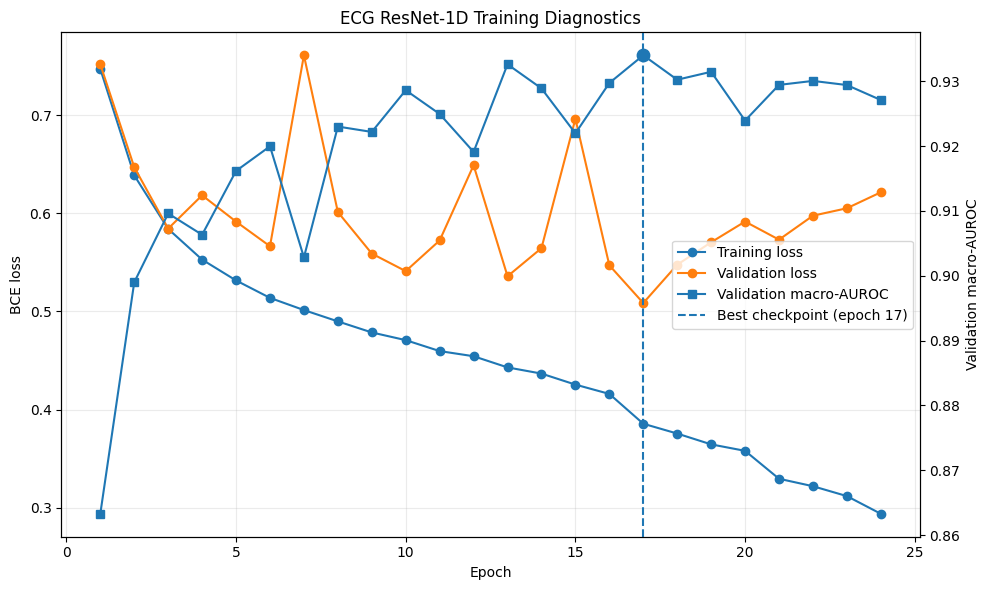


LEARNING-RATE CHANGES
----------------------------------------------------------------------
 epoch  learning_rate  lr_changed
     1       0.001000        True
    16       0.000500        True
    20       0.000250        True
    23       0.000125        True

OUTPUTS
----------------------------------------------------------------------
/content/drive/MyDrive/PTB-XL Research Project/results/deep_learning/figure_10I_training_diagnostics.png
/content/drive/MyDrive/PTB-XL Research Project/results/deep_learning/ecg_resnet1d_training_diagnostics.csv

STEP 10I STATUS: PASS


In [24]:
# ============================================================
# STEP 10I — TRAINING DIAGNOSTICS & LEARNING CURVES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 10I — TRAINING DIAGNOSTICS & LEARNING CURVES")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load frozen training history
# ------------------------------------------------------------

HISTORY_PATH_10I = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning/ecg_resnet1d_training_history.csv"
)

history_10I = pd.read_csv(HISTORY_PATH_10I)

print("\nTRAINING HISTORY")
print("-" * 70)
print(f"Rows: {len(history_10I)}")
print(f"Columns: {history_10I.columns.tolist()}")

# ------------------------------------------------------------
# 2. Validate actual history schema
# ------------------------------------------------------------

required_columns_10I = [
    "epoch",
    "train_loss",
    "validation_loss",
    "validation_macro_auroc",
    "learning_rate",
    "epoch_time_seconds"
]

missing_columns_10I = [
    col for col in required_columns_10I
    if col not in history_10I.columns
]

if missing_columns_10I:
    raise ValueError(
        f"Missing required history columns: "
        f"{missing_columns_10I}"
    )

assert len(history_10I) == 24
assert history_10I["epoch"].is_unique
assert history_10I["epoch"].tolist() == list(range(1, 25))

for col in required_columns_10I:
    assert np.isfinite(
        history_10I[col].to_numpy(dtype=float)
    ).all()

# ------------------------------------------------------------
# 3. Identify best checkpoint
# ------------------------------------------------------------

best_row_10I = history_10I.loc[
    history_10I["validation_macro_auroc"].idxmax()
]

best_epoch_10I = int(
    best_row_10I["epoch"]
)

best_val_auroc_10I = float(
    best_row_10I["validation_macro_auroc"]
)

assert best_epoch_10I == 17
assert abs(best_val_auroc_10I - 0.934005) < 1e-5

# ------------------------------------------------------------
# 4. Training diagnostics summary
# ------------------------------------------------------------

initial_train_loss_10I = float(
    history_10I.iloc[0]["train_loss"]
)

final_train_loss_10I = float(
    history_10I.iloc[-1]["train_loss"]
)

initial_val_loss_10I = float(
    history_10I.iloc[0]["validation_loss"]
)

best_val_loss_10I = float(
    history_10I["validation_loss"].min()
)

best_val_loss_epoch_10I = int(
    history_10I.loc[
        history_10I["validation_loss"].idxmin(),
        "epoch"
    ]
)

final_val_loss_10I = float(
    history_10I.iloc[-1]["validation_loss"]
)

initial_lr_10I = float(
    history_10I.iloc[0]["learning_rate"]
)

final_lr_10I = float(
    history_10I.iloc[-1]["learning_rate"]
)

total_training_time_10I = float(
    history_10I["epoch_time_seconds"].sum()
)

print("\nKEY TRAINING RESULTS")
print("-" * 70)
print(f"Epochs completed:          {len(history_10I)}")
print(f"Best epoch:                {best_epoch_10I}")
print(f"Best validation AUROC:     {best_val_auroc_10I:.6f}")
print(f"Initial training loss:     {initial_train_loss_10I:.6f}")
print(f"Final training loss:       {final_train_loss_10I:.6f}")
print(f"Initial validation loss:   {initial_val_loss_10I:.6f}")
print(
    f"Best validation loss:       "
    f"{best_val_loss_10I:.6f} "
    f"(epoch {best_val_loss_epoch_10I})"
)
print(f"Final validation loss:      {final_val_loss_10I:.6f}")
print(f"Initial learning rate:      {initial_lr_10I:.6f}")
print(f"Final learning rate:        {final_lr_10I:.6f}")
print(
    f"Total recorded training time: "
    f"{total_training_time_10I / 60:.2f} min"
)

# ------------------------------------------------------------
# 5. Learning curves
# ------------------------------------------------------------

FIGURE_PATH_10I = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning/"
    "figure_10I_training_diagnostics.png"
)

epochs_10I = history_10I["epoch"]

fig, ax1 = plt.subplots(
    figsize=(10, 6)
)

# Training and validation loss
ax1.plot(
    epochs_10I,
    history_10I["train_loss"],
    marker="o",
    label="Training loss"
)

ax1.plot(
    epochs_10I,
    history_10I["validation_loss"],
    marker="o",
    label="Validation loss"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE loss")
ax1.set_title(
    "ECG ResNet-1D Training Diagnostics"
)

ax1.grid(True, alpha=0.25)

# Validation AUROC
ax2 = ax1.twinx()

ax2.plot(
    epochs_10I,
    history_10I["validation_macro_auroc"],
    marker="s",
    label="Validation macro-AUROC"
)

ax2.axvline(
    best_epoch_10I,
    linestyle="--",
    linewidth=1.5,
    label=f"Best checkpoint (epoch {best_epoch_10I})"
)

ax2.scatter(
    [best_epoch_10I],
    [best_val_auroc_10I],
    s=80,
    zorder=5
)

ax2.set_ylabel("Validation macro-AUROC")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="center right"
)

fig.tight_layout()

fig.savefig(
    FIGURE_PATH_10I,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 6. Learning-rate changes
# ------------------------------------------------------------

lr_changes_10I = history_10I[
    ["epoch", "learning_rate"]
].copy()

lr_changes_10I["lr_changed"] = (
    lr_changes_10I["learning_rate"]
    .ne(
        lr_changes_10I["learning_rate"].shift()
    )
)

print("\nLEARNING-RATE CHANGES")
print("-" * 70)

print(
    lr_changes_10I[
        lr_changes_10I["lr_changed"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 7. Save diagnostics summary
# ------------------------------------------------------------

DIAGNOSTICS_PATH_10I = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning/"
    "ecg_resnet1d_training_diagnostics.csv"
)

diagnostics_summary_10I = pd.DataFrame([{
    "epochs_completed": len(history_10I),
    "best_epoch": best_epoch_10I,
    "best_validation_macro_auroc": best_val_auroc_10I,
    "initial_train_loss": initial_train_loss_10I,
    "final_train_loss": final_train_loss_10I,
    "initial_validation_loss": initial_val_loss_10I,
    "best_validation_loss": best_val_loss_10I,
    "best_validation_loss_epoch": best_val_loss_epoch_10I,
    "final_validation_loss": final_val_loss_10I,
    "initial_learning_rate": initial_lr_10I,
    "final_learning_rate": final_lr_10I,
    "total_training_time_seconds": total_training_time_10I
}])

diagnostics_summary_10I.to_csv(
    DIAGNOSTICS_PATH_10I,
    index=False
)

# ------------------------------------------------------------
# 8. Final validation
# ------------------------------------------------------------

assert os.path.exists(FIGURE_PATH_10I)
assert os.path.exists(DIAGNOSTICS_PATH_10I)

print("\nOUTPUTS")
print("-" * 70)
print(FIGURE_PATH_10I)
print(DIAGNOSTICS_PATH_10I)

print("\n" + "=" * 70)
print("STEP 10I STATUS: PASS")
print("=" * 70)

In [27]:
# ============================================================
# STEP 10J — DEEP LEARNING VS FEATURE-BASED ML COMPARISON
# ============================================================

import os
import numpy as np
import pandas as pd

print("=" * 70)
print("STEP 10J — DEEP LEARNING VS FEATURE-BASED ML COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

BASELINE_PATH_10J = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/baseline_ml"
)

DEEP_PATH_10J = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning"
)

LOGISTIC_RESULTS_PATH_10J = os.path.join(
    BASELINE_PATH_10J,
    "logistic_regression_validation_auroc.csv"
)

RF_COMPARISON_PATH_10J = os.path.join(
    BASELINE_PATH_10J,
    "feature_based_baseline_comparison_validation.csv"
)

DL_HISTORY_PATH_10J = os.path.join(
    DEEP_PATH_10J,
    "ecg_resnet1d_training_history.csv"
)

DL_TEST_RESULTS_PATH_10J = os.path.join(
    DEEP_PATH_10J,
    "ecg_resnet1d_test_results.csv"
)

# ------------------------------------------------------------
# 2. Load frozen artifacts
# ------------------------------------------------------------

logistic_10J = pd.read_csv(
    LOGISTIC_RESULTS_PATH_10J
)

rf_comparison_10J = pd.read_csv(
    RF_COMPARISON_PATH_10J
)

history_10J = pd.read_csv(
    DL_HISTORY_PATH_10J
)

dl_test_10J = pd.read_csv(
    DL_TEST_RESULTS_PATH_10J
)

print("\nLOADED ARTIFACTS")
print("-" * 70)
print(f"Logistic Regression rows: {len(logistic_10J)}")
print(f"RF comparison rows:       {len(rf_comparison_10J)}")
print(f"DL history rows:          {len(history_10J)}")
print(f"DL test result rows:      {len(dl_test_10J)}")

# ------------------------------------------------------------
# 3. Display target labels for schema verification
# ------------------------------------------------------------

print("\nRF COMPARISON TARGETS")
print("-" * 70)
print(
    rf_comparison_10J["target"].tolist()
)

# ------------------------------------------------------------
# 4. Keep ONLY the five locked diagnostic targets
# ------------------------------------------------------------

TARGETS_10J = [
    "MI",
    "STTC",
    "CD",
    "HYP",
    "NORM"
]

rf_class_10J = rf_comparison_10J[
    rf_comparison_10J["target"].isin(TARGETS_10J)
].copy()

logistic_class_10J = logistic_10J[
    logistic_10J["target"].isin(TARGETS_10J)
].copy()

assert len(rf_class_10J) == 5
assert len(logistic_class_10J) == 5

assert set(
    rf_class_10J["target"]
) == set(TARGETS_10J)

assert set(
    logistic_class_10J["target"]
) == set(TARGETS_10J)

# ------------------------------------------------------------
# 5. Extract feature-based AUROC values
# ------------------------------------------------------------

if "Random_Forest_AUROC" not in rf_class_10J.columns:
    raise ValueError(
        "Random_Forest_AUROC column not found."
    )

if "Logistic_Regression_AUROC" not in rf_class_10J.columns:
    raise ValueError(
        "Logistic_Regression_AUROC column not found."
    )

per_class_comparison_10J = (
    rf_class_10J[
        [
            "target",
            "Logistic_Regression_AUROC",
            "Random_Forest_AUROC"
        ]
    ]
    .copy()
)

per_class_comparison_10J.columns = [
    "target",
    "logistic_auroc",
    "random_forest_auroc"
]

# ------------------------------------------------------------
# 6. Calculate RF improvement over Logistic Regression
# ------------------------------------------------------------

per_class_comparison_10J[
    "RF_improvement_vs_logistic"
] = (
    per_class_comparison_10J[
        "random_forest_auroc"
    ]
    -
    per_class_comparison_10J[
        "logistic_auroc"
    ]
)

per_class_comparison_10J = (
    per_class_comparison_10J
    .sort_values(
        "target",
        key=lambda x: x.map(
            {target: i for i, target in enumerate(TARGETS_10J)}
        )
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Calculate feature-based macro-AUROC
# ------------------------------------------------------------

logistic_macro_10J = float(
    per_class_comparison_10J[
        "logistic_auroc"
    ].mean()
)

rf_macro_10J = float(
    per_class_comparison_10J[
        "random_forest_auroc"
    ].mean()
)

print("\nFEATURE-BASED VALIDATION MACRO-AUROC")
print("-" * 70)
print(
    f"Logistic Regression: {logistic_macro_10J:.6f}"
)
print(
    f"Random Forest:       {rf_macro_10J:.6f}"
)

assert abs(
    logistic_macro_10J - 0.862716
) < 1e-5

assert abs(
    rf_macro_10J - 0.874342
) < 1e-5

# ------------------------------------------------------------
# 8. Extract ResNet validation macro-AUROC
# ------------------------------------------------------------

required_history_columns_10J = [
    "epoch",
    "validation_macro_auroc"
]

for col in required_history_columns_10J:
    if col not in history_10J.columns:
        raise ValueError(
            f"Missing '{col}' from DL history. "
            f"Available: {history_10J.columns.tolist()}"
        )

best_dl_row_10J = history_10J.loc[
    history_10J[
        "validation_macro_auroc"
    ].idxmax()
]

best_dl_epoch_10J = int(
    best_dl_row_10J["epoch"]
)

best_dl_macro_auroc_10J = float(
    best_dl_row_10J["validation_macro_auroc"]
)

assert best_dl_epoch_10J == 17
assert abs(
    best_dl_macro_auroc_10J - 0.934005
) < 1e-5

# ------------------------------------------------------------
# 9. Model-level validation comparison
# ------------------------------------------------------------

comparison_10J = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "representation": "120 engineered ECG features",
        "validation_macro_AUROC": logistic_macro_10J
    },
    {
        "model": "Random Forest",
        "representation": "120 engineered ECG features",
        "validation_macro_AUROC": rf_macro_10J
    },
    {
        "model": "ResNet-1D",
        "representation": "Raw 12-lead ECG waveform",
        "validation_macro_AUROC": best_dl_macro_auroc_10J
    }
])

comparison_10J[
    "improvement_vs_logistic"
] = (
    comparison_10J[
        "validation_macro_AUROC"
    ]
    - logistic_macro_10J
)

comparison_10J[
    "improvement_vs_random_forest"
] = (
    comparison_10J[
        "validation_macro_AUROC"
    ]
    - rf_macro_10J
)

# ------------------------------------------------------------
# 10. Verify locked ResNet test result
# ------------------------------------------------------------

if "AUROC" not in dl_test_10J.columns:
    raise ValueError(
        f"Expected 'AUROC' in DL test results. "
        f"Available: {dl_test_10J.columns.tolist()}"
    )

dl_test_macro_10J = float(
    dl_test_10J["AUROC"].mean()
)

assert len(dl_test_10J) == 5

assert abs(
    dl_test_macro_10J - 0.930060
) < 1e-5

# ------------------------------------------------------------
# 11. Save comparison artifacts
# ------------------------------------------------------------

MODEL_COMPARISON_PATH_10J = os.path.join(
    DEEP_PATH_10J,
    "ecg_model_comparison_validation.csv"
)

PER_CLASS_BASELINE_PATH_10J = os.path.join(
    DEEP_PATH_10J,
    "ecg_feature_based_per_class_comparison_validation.csv"
)

TEST_SUMMARY_PATH_10J = os.path.join(
    DEEP_PATH_10J,
    "ecg_resnet1d_locked_test_summary.csv"
)

comparison_10J.to_csv(
    MODEL_COMPARISON_PATH_10J,
    index=False
)

per_class_comparison_10J.to_csv(
    PER_CLASS_BASELINE_PATH_10J,
    index=False
)

locked_test_summary_10J = pd.DataFrame([{
    "model": "ResNet-1D",
    "checkpoint_epoch": best_dl_epoch_10J,
    "validation_macro_AUROC": best_dl_macro_auroc_10J,
    "locked_test_macro_AUROC": dl_test_macro_10J,
    "test_ECGs": 2198
}])

locked_test_summary_10J.to_csv(
    TEST_SUMMARY_PATH_10J,
    index=False
)

# ------------------------------------------------------------
# 12. Print final results
# ------------------------------------------------------------

print("\nVALIDATION MODEL COMPARISON")
print("-" * 70)

print(
    comparison_10J.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nPER-CLASS FEATURE-BASED COMPARISON")
print("-" * 70)

print(
    per_class_comparison_10J.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nLOCKED RESNET TEST RESULT")
print("-" * 70)
print(
    f"Checkpoint epoch:       "
    f"{best_dl_epoch_10J}"
)
print(
    f"Validation macro-AUROC: "
    f"{best_dl_macro_auroc_10J:.6f}"
)
print(
    f"Test macro-AUROC:       "
    f"{dl_test_macro_10J:.6f}"
)
print("Test ECGs:              2,198")

print("\nKEY IMPROVEMENTS")
print("-" * 70)
print(
    f"ResNet vs Logistic Regression: "
    f"{best_dl_macro_auroc_10J - logistic_macro_10J:+.6f}"
)
print(
    f"ResNet vs Random Forest:       "
    f"{best_dl_macro_auroc_10J - rf_macro_10J:+.6f}"
)

# ------------------------------------------------------------
# 13. Final validation
# ------------------------------------------------------------

assert len(comparison_10J) == 3
assert len(per_class_comparison_10J) == 5

assert np.isfinite(
    comparison_10J[
        "validation_macro_AUROC"
    ]
).all()

assert os.path.exists(
    MODEL_COMPARISON_PATH_10J
)

assert os.path.exists(
    PER_CLASS_BASELINE_PATH_10J
)

assert os.path.exists(
    TEST_SUMMARY_PATH_10J
)

print("\nOUTPUTS")
print("-" * 70)
print(MODEL_COMPARISON_PATH_10J)
print(PER_CLASS_BASELINE_PATH_10J)
print(TEST_SUMMARY_PATH_10J)

print("\n" + "=" * 70)
print("STEP 10J STATUS: PASS")
print("=" * 70)

STEP 10J — DEEP LEARNING VS FEATURE-BASED ML COMPARISON

LOADED ARTIFACTS
----------------------------------------------------------------------
Logistic Regression rows: 6
RF comparison rows:       6
DL history rows:          24
DL test result rows:      5

RF COMPARISON TARGETS
----------------------------------------------------------------------
['MI', 'STTC', 'CD', 'HYP', 'NORM', 'MACRO']

FEATURE-BASED VALIDATION MACRO-AUROC
----------------------------------------------------------------------
Logistic Regression: 0.862716
Random Forest:       0.874342

VALIDATION MODEL COMPARISON
----------------------------------------------------------------------
              model              representation  validation_macro_AUROC  improvement_vs_logistic  improvement_vs_random_forest
Logistic Regression 120 engineered ECG features                0.862716                 0.000000                     -0.011626
      Random Forest 120 engineered ECG features                0.874342         

In [29]:
# ============================================================
# STEP 10K-A — INSPECT FROZEN CHECKPOINT SCHEMA
# ============================================================

print("=" * 70)
print("STEP 10K-A — CHECKPOINT SCHEMA INSPECTION")
print("=" * 70)

print("\nCHECKPOINT TYPE")
print("-" * 70)
print(type(checkpoint_10K))

print("\nCHECKPOINT KEYS")
print("-" * 70)

if isinstance(checkpoint_10K, dict):
    for key_10K, value_10K in checkpoint_10K.items():
        if isinstance(value_10K, dict):
            print(
                f"{key_10K}: dict "
                f"({len(value_10K)} entries)"
            )
        elif hasattr(value_10K, "shape"):
            print(
                f"{key_10K}: "
                f"{type(value_10K).__name__}, "
                f"shape={value_10K.shape}"
            )
        elif isinstance(value_10K, (list, tuple)):
            print(
                f"{key_10K}: "
                f"{type(value_10K).__name__}, "
                f"length={len(value_10K)}"
            )
        else:
            print(
                f"{key_10K}: "
                f"{type(value_10K).__name__} = "
                f"{value_10K}"
            )
else:
    print("Checkpoint is not a dictionary.")

print("\n" + "=" * 70)
print("STEP 10K-A STATUS: INSPECTION COMPLETE")
print("=" * 70)

STEP 10K-A — CHECKPOINT SCHEMA INSPECTION

CHECKPOINT TYPE
----------------------------------------------------------------------
<class 'dict'>

CHECKPOINT KEYS
----------------------------------------------------------------------
epoch: int = 17
model_state_dict: dict (122 entries)
optimizer_state_dict: dict (2 entries)
scheduler_state_dict: dict (15 entries)
best_validation_macro_auroc: float = 0.9340045897528851
target_columns: list, length=5
model_parameters: int = 8739973

STEP 10K-A STATUS: INSPECTION COMPLETE


In [30]:
# ============================================================
# STEP 10K — FREEZE DEEP-LEARNING BASELINE
# ============================================================

import os
import hashlib
import json
import numpy as np
import pandas as pd

print("=" * 70)
print("STEP 10K — FREEZE DEEP-LEARNING BASELINE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

DEEP_PATH_10K = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "results/deep_learning"
)

CHECKPOINT_PATH_10K = os.path.join(
    DEEP_PATH_10K,
    "ecg_resnet1d_best_validation.pt"
)

HISTORY_PATH_10K = os.path.join(
    DEEP_PATH_10K,
    "ecg_resnet1d_training_history.csv"
)

TEST_RESULTS_PATH_10K = os.path.join(
    DEEP_PATH_10K,
    "ecg_resnet1d_test_results.csv"
)

MODEL_COMPARISON_PATH_10K = os.path.join(
    DEEP_PATH_10K,
    "ecg_model_comparison_validation.csv"
)

TRAINING_DIAGNOSTICS_PATH_10K = os.path.join(
    DEEP_PATH_10K,
    "ecg_resnet1d_training_diagnostics.csv"
)

# ------------------------------------------------------------
# 2. Verify required artifacts
# ------------------------------------------------------------

required_artifacts_10K = {
    "checkpoint": CHECKPOINT_PATH_10K,
    "training_history": HISTORY_PATH_10K,
    "test_results": TEST_RESULTS_PATH_10K,
    "model_comparison": MODEL_COMPARISON_PATH_10K,
    "training_diagnostics": TRAINING_DIAGNOSTICS_PATH_10K
}

for artifact_name_10K, artifact_path_10K in required_artifacts_10K.items():

    if not os.path.exists(artifact_path_10K):
        raise FileNotFoundError(
            f"Missing required {artifact_name_10K}: "
            f"{artifact_path_10K}"
        )

print("\nREQUIRED ARTIFACTS")
print("-" * 70)

for artifact_name_10K in required_artifacts_10K:
    print(f"{artifact_name_10K}: PASS")

# ------------------------------------------------------------
# 3. Load frozen artifacts
# ------------------------------------------------------------

checkpoint_10K = torch.load(
    CHECKPOINT_PATH_10K,
    map_location="cpu"
)

history_10K = pd.read_csv(
    HISTORY_PATH_10K
)

test_results_10K = pd.read_csv(
    TEST_RESULTS_PATH_10K
)

model_comparison_10K = pd.read_csv(
    MODEL_COMPARISON_PATH_10K
)

training_diagnostics_10K = pd.read_csv(
    TRAINING_DIAGNOSTICS_PATH_10K
)

# ------------------------------------------------------------
# 4. Validate checkpoint
# ------------------------------------------------------------

assert isinstance(checkpoint_10K, dict)

assert checkpoint_10K["epoch"] == 17

checkpoint_val_auroc_10K = float(
    checkpoint_10K[
        "best_validation_macro_auroc"
    ]
)

assert abs(
    checkpoint_val_auroc_10K - 0.934005
) < 1e-5

assert checkpoint_10K[
    "target_columns"
] == TARGET_COLUMNS_10F

checkpoint_parameter_count_10K = int(
    checkpoint_10K["model_parameters"]
)

assert checkpoint_parameter_count_10K == 8739973

# ------------------------------------------------------------
# 5. Validate training history
# ------------------------------------------------------------

assert len(history_10K) == 24

best_history_row_10K = history_10K.loc[
    history_10K[
        "validation_macro_auroc"
    ].idxmax()
]

assert int(
    best_history_row_10K["epoch"]
) == 17

assert abs(
    float(
        best_history_row_10K[
            "validation_macro_auroc"
        ]
    )
    - checkpoint_val_auroc_10K
) < 1e-5

# ------------------------------------------------------------
# 6. Validate locked test results
# ------------------------------------------------------------

assert len(test_results_10K) == 5

test_macro_auroc_10K = float(
    test_results_10K["AUROC"].mean()
)

test_macro_auprc_10K = float(
    test_results_10K["AUPRC"].mean()
)

test_macro_f1_10K = float(
    test_results_10K["F1"].mean()
)

test_macro_sensitivity_10K = float(
    test_results_10K["sensitivity"].mean()
)

test_macro_specificity_10K = float(
    test_results_10K["specificity"].mean()
)

assert abs(
    test_macro_auroc_10K - 0.930060
) < 1e-5

# ------------------------------------------------------------
# 7. Validate model comparison
# ------------------------------------------------------------

assert len(model_comparison_10K) == 3

resnet_row_10K = model_comparison_10K[
    model_comparison_10K["model"] == "ResNet-1D"
]

rf_row_10K = model_comparison_10K[
    model_comparison_10K["model"] == "Random Forest"
]

logistic_row_10K = model_comparison_10K[
    model_comparison_10K["model"]
    == "Logistic Regression"
]

assert len(resnet_row_10K) == 1
assert len(rf_row_10K) == 1
assert len(logistic_row_10K) == 1

resnet_val_auroc_10K = float(
    resnet_row_10K.iloc[0][
        "validation_macro_AUROC"
    ]
)

rf_val_auroc_10K = float(
    rf_row_10K.iloc[0][
        "validation_macro_AUROC"
    ]
)

logistic_val_auroc_10K = float(
    logistic_row_10K.iloc[0][
        "validation_macro_AUROC"
    ]
)

assert abs(
    resnet_val_auroc_10K - 0.934005
) < 1e-5

assert abs(
    rf_val_auroc_10K - 0.874342
) < 1e-5

assert abs(
    logistic_val_auroc_10K - 0.862716
) < 1e-5

resnet_vs_rf_10K = (
    resnet_val_auroc_10K
    - rf_val_auroc_10K
)

resnet_vs_logistic_10K = (
    resnet_val_auroc_10K
    - logistic_val_auroc_10K
)

# ------------------------------------------------------------
# 8. Validation-to-test difference
# ------------------------------------------------------------

validation_test_gap_10K = (
    resnet_val_auroc_10K
    - test_macro_auroc_10K
)

# ------------------------------------------------------------
# 9. SHA-256 artifact hashes
# ------------------------------------------------------------

def sha256_file_10K(path):

    sha256 = hashlib.sha256()

    with open(path, "rb") as file_10K:

        for chunk_10K in iter(
            lambda: file_10K.read(1024 * 1024),
            b""
        ):
            sha256.update(chunk_10K)

    return sha256.hexdigest()


artifact_hashes_10K = {}

for artifact_name_10K, artifact_path_10K in required_artifacts_10K.items():

    artifact_hashes_10K[
        artifact_name_10K
    ] = sha256_file_10K(
        artifact_path_10K
    )

# ------------------------------------------------------------
# 10. Create frozen baseline record
# ------------------------------------------------------------

FREEZE_PATH_10K = os.path.join(
    DEEP_PATH_10K,
    "ecg_resnet1d_frozen_baseline.json"
)

frozen_baseline_10K = {
    "status": "FROZEN",
    "notebook": "10_ecg_deep_learning_generalization",
    "model": "ECGResNet1D",
    "architecture": "1D ResNet",
    "input_representation": "raw 12-lead ECG waveform",
    "input_shape": [12, 5000],
    "sampling_frequency_hz": 500,
    "duration_seconds": 10,
    "number_of_targets": 5,
    "targets": TARGET_COLUMNS_10F,
    "parameter_count": checkpoint_parameter_count_10K,
    "train_samples": 17418,
    "validation_samples": 2183,
    "test_samples": 2198,
    "split": "patient-independent",
    "patient_overlap": 0,
    "loss": "BCEWithLogitsLoss with training-set positive class weights",
    "optimizer": "AdamW",
    "initial_learning_rate": 0.001,
    "weight_decay": 0.0001,
    "scheduler": "ReduceLROnPlateau",
    "max_epochs": 30,
    "epochs_completed": 24,
    "early_stopping_patience": 7,
    "selected_checkpoint_epoch": 17,
    "selection_metric": "validation macro-AUROC",
    "validation_macro_AUROC": resnet_val_auroc_10K,
    "test_macro_AUROC": test_macro_auroc_10K,
    "test_macro_AUPRC": test_macro_auprc_10K,
    "test_macro_F1": test_macro_f1_10K,
    "test_macro_sensitivity": test_macro_sensitivity_10K,
    "test_macro_specificity": test_macro_specificity_10K,
    "validation_to_test_AUROC_gap": validation_test_gap_10K,
    "random_forest_validation_macro_AUROC": rf_val_auroc_10K,
    "logistic_regression_validation_macro_AUROC": logistic_val_auroc_10K,
    "resnet_improvement_vs_random_forest": resnet_vs_rf_10K,
    "resnet_improvement_vs_logistic": resnet_vs_logistic_10K,
    "test_set_used_for_model_selection": False,
    "test_set_used_for_threshold_tuning": False,
    "test_set_used_for_hyperparameter_tuning": False,
    "future_model_selection_using_test_set": False,
    "artifact_sha256": artifact_hashes_10K
}

with open(
    FREEZE_PATH_10K,
    "w"
) as file_10K:

    json.dump(
        frozen_baseline_10K,
        file_10K,
        indent=2
    )

# ------------------------------------------------------------
# 11. Print freeze summary
# ------------------------------------------------------------

print("\nFROZEN BASELINE")
print("-" * 70)
print(
    f"Model:                    "
    f"{frozen_baseline_10K['model']}"
)
print(
    f"Representation:           "
    f"{frozen_baseline_10K['input_representation']}"
)
print(
    f"Parameters:               "
    f"{checkpoint_parameter_count_10K:,}"
)
print(
    f"Selected checkpoint:      "
    f"Epoch {frozen_baseline_10K['selected_checkpoint_epoch']}"
)
print(
    f"Validation macro-AUROC:   "
    f"{resnet_val_auroc_10K:.6f}"
)
print(
    f"Locked test macro-AUROC:  "
    f"{test_macro_auroc_10K:.6f}"
)
print(
    f"Validation → test gap:    "
    f"{validation_test_gap_10K:.6f}"
)
print(
    f"vs Random Forest:         "
    f"{resnet_vs_rf_10K:+.6f}"
)
print(
    f"vs Logistic Regression:   "
    f"{resnet_vs_logistic_10K:+.6f}"
)

print("\nTEST METRICS")
print("-" * 70)
print(
    f"Macro-AUROC:              "
    f"{test_macro_auroc_10K:.6f}"
)
print(
    f"Macro-AUPRC:              "
    f"{test_macro_auprc_10K:.6f}"
)
print(
    f"Macro-F1:                 "
    f"{test_macro_f1_10K:.6f}"
)
print(
    f"Macro-sensitivity:        "
    f"{test_macro_sensitivity_10K:.6f}"
)
print(
    f"Macro-specificity:        "
    f"{test_macro_specificity_10K:.6f}"
)

print("\nARTIFACT INTEGRITY")
print("-" * 70)

for artifact_name_10K, artifact_hash_10K in artifact_hashes_10K.items():

    print(
        f"{artifact_name_10K}: "
        f"{artifact_hash_10K[:16]}..."
    )

print("\nFREEZE RECORD")
print("-" * 70)
print(FREEZE_PATH_10K)

# ------------------------------------------------------------
# 12. Final validation
# ------------------------------------------------------------

assert os.path.exists(
    FREEZE_PATH_10K
)

with open(
    FREEZE_PATH_10K,
    "r"
) as file_10K:

    frozen_check_10K = json.load(
        file_10K
    )

assert frozen_check_10K["status"] == "FROZEN"
assert frozen_check_10K["selected_checkpoint_epoch"] == 17
assert frozen_check_10K[
    "test_set_used_for_model_selection"
] is False
assert frozen_check_10K[
    "future_model_selection_using_test_set"
] is False

print("\n" + "=" * 70)
print("STEP 10K STATUS: PASS — DEEP-LEARNING BASELINE FROZEN")
print("=" * 70)

STEP 10K — FREEZE DEEP-LEARNING BASELINE

REQUIRED ARTIFACTS
----------------------------------------------------------------------
checkpoint: PASS
training_history: PASS
test_results: PASS
model_comparison: PASS
training_diagnostics: PASS

FROZEN BASELINE
----------------------------------------------------------------------
Model:                    ECGResNet1D
Representation:           raw 12-lead ECG waveform
Parameters:               8,739,973
Selected checkpoint:      Epoch 17
Validation macro-AUROC:   0.934005
Locked test macro-AUROC:  0.930060
Validation → test gap:    0.003945
vs Random Forest:         +0.059662
vs Logistic Regression:   +0.071288

TEST METRICS
----------------------------------------------------------------------
Macro-AUROC:              0.930060
Macro-AUPRC:              0.824810
Macro-F1:                 0.718363
Macro-sensitivity:        0.852513
Macro-specificity:        0.851310

ARTIFACT INTEGRITY
------------------------------------------------------

In [31]:
# ============================================================
# STEP 10L — FINAL NOTEBOOK 10 SUMMARY
# ============================================================

print("=" * 70)
print("NOTEBOOK 10 — ECG DEEP LEARNING GENERALIZATION")
print("FINAL SUMMARY")
print("=" * 70)

print("""
OBJECTIVE
----------------------------------------------------------------------
Evaluate whether a raw-waveform 1D ResNet can provide strong
patient-independent diagnostic generalization on PTB-XL and compare
its performance with the frozen engineered-feature ML baselines.

DATASET
----------------------------------------------------------------------
Dataset:                 PTB-XL v1.0.3
ECGs:                    21,799
Leads:                   12
Sampling frequency:      500 Hz
Duration:                10 seconds
Targets:                 MI, STTC, CD, HYP, NORM

PATIENT-INDEPENDENT SPLIT
----------------------------------------------------------------------
Training ECGs:           17,418
Validation ECGs:          2,183
Test ECGs:                2,198
Patient overlap:              0

RAW-WAVEFORM PIPELINE
----------------------------------------------------------------------
Representation:          Raw 12-lead ECG waveform
Input tensor:             (12, 5000)
Preprocessing:            No additional signal preprocessing
Architecture:             1D ResNet
Parameters:               8,739,973

TRAINING PROTOCOL
----------------------------------------------------------------------
Loss:                     BCEWithLogitsLoss
Class weighting:          Training-set positive class weights
Optimizer:                AdamW
Initial learning rate:    0.001
Weight decay:             0.0001
Scheduler:                ReduceLROnPlateau
Maximum epochs:           30
Epochs completed:         24
Early stopping patience:  7
Selection metric:         Validation macro-AUROC
Best checkpoint:          Epoch 17

VALIDATION PERFORMANCE
----------------------------------------------------------------------
Logistic Regression:      0.862716
Random Forest:             0.874342
ResNet-1D:                 0.934005

ResNet vs Logistic:       +0.071288
ResNet vs Random Forest:  +0.059662

LOCKED TEST PERFORMANCE
----------------------------------------------------------------------
Macro-AUROC:              0.930060
Macro-AUPRC:              0.824810
Macro-F1:                 0.718363
Macro-sensitivity:        0.852513
Macro-specificity:        0.851310

VALIDATION → TEST
----------------------------------------------------------------------
Validation macro-AUROC:   0.934005
Test macro-AUROC:         0.930060
Absolute gap:             0.003945

PER-CLASS TEST AUROC
----------------------------------------------------------------------
MI:                       0.934836
STTC:                     0.933429
CD:                       0.924570
HYP:                      0.909130
NORM:                     0.948333

METHODOLOGICAL SAFEGUARDS
----------------------------------------------------------------------
- Patient-independent train/validation/test split.
- Zero patient overlap between all partitions.
- Test set excluded from training.
- Test set excluded from hyperparameter selection.
- Test set excluded from checkpoint selection.
- Test set excluded from threshold tuning.
- Best checkpoint selected using validation macro-AUROC only.
- Locked test evaluation performed once after model selection.
- Classical and deep-learning baselines remain distinguishable.
- Frozen baseline artifacts were integrity-checked using SHA-256.

KEY SCIENTIFIC FINDING
----------------------------------------------------------------------
The raw-waveform ResNet-1D substantially outperformed the engineered
feature-based baselines on the patient-independent validation set,
while maintaining a similar macro-AUROC on the locked test set.

This supports the use of raw 12-lead waveform learning as the primary
deep-learning baseline for subsequent robustness experiments.

IMPORTANT INTERPRETATION
----------------------------------------------------------------------
The purpose of Notebook 10 is not to establish clinical superiority
or a definitive diagnostic system.

It establishes a strong patient-independent raw-waveform deep-learning
baseline against which robustness to realistic ECG signal-quality
conditions and preprocessing strategies can be evaluated.

FROZEN ARTIFACT
----------------------------------------------------------------------
/content/drive/MyDrive/PTB-XL Research Project/results/deep_learning/ecg_resnet1d_frozen_baseline.json

STATUS
----------------------------------------------------------------------
Notebook 10A–10K: PASS
Notebook 10L:       COMPLETE
Notebook 10:         COMPLETE / FROZEN

NEXT STAGE
----------------------------------------------------------------------
Notebook 11 — Noise Robustness and Signal-Quality Generalization
""")

# ------------------------------------------------------------
# Final consistency checks
# ------------------------------------------------------------

assert checkpoint_parameter_count_10K == 8739973
assert resnet_val_auroc_10K > rf_val_auroc_10K
assert rf_val_auroc_10K > logistic_val_auroc_10K
assert abs(test_macro_auroc_10K - 0.930060) < 1e-5
assert abs(validation_test_gap_10K - 0.003945) < 1e-5
assert len(test_results_10K) == 5
assert len(history_10K) == 24
assert os.path.exists(FREEZE_PATH_10K)

print("\n" + "=" * 70)
print("STEP 10L STATUS: PASS")
print("NOTEBOOK 10 STATUS: COMPLETE / FROZEN")
print("=" * 70)

NOTEBOOK 10 — ECG DEEP LEARNING GENERALIZATION
FINAL SUMMARY

OBJECTIVE
----------------------------------------------------------------------
Evaluate whether a raw-waveform 1D ResNet can provide strong
patient-independent diagnostic generalization on PTB-XL and compare
its performance with the frozen engineered-feature ML baselines.

DATASET
----------------------------------------------------------------------
Dataset:                 PTB-XL v1.0.3
ECGs:                    21,799
Leads:                   12
Sampling frequency:      500 Hz
Duration:                10 seconds
Targets:                 MI, STTC, CD, HYP, NORM

PATIENT-INDEPENDENT SPLIT
----------------------------------------------------------------------
Training ECGs:           17,418
Validation ECGs:          2,183
Test ECGs:                2,198
Patient overlap:              0

RAW-WAVEFORM PIPELINE
----------------------------------------------------------------------
Representation:          Raw 12-lead ECG wavefo